# 🧪 ElectioAnalytics — Test du Dataset ML Final
**Objectif :** Vérifier la qualité et la cohérence du dataset avant le preprocessing ML  
**Fichier testé :** `data/final/dataset_ml_final.csv`  
**Étapes :**
1. Chargement & structure
2. Valeurs manquantes
3. Distribution des variables cibles
4. Statistiques descriptives des features socio-éco
5. Corrélations avec la variable cible
6. Cohérence temporelle (2017 vs 2022)
7. Détection des outliers
8. Bilan final

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

# Style global
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

print('✅ Imports OK')

✅ Imports OK


---
## Étape 1 — Chargement & Structure

In [2]:
df = pd.read_csv('../data/final/dataset_ml_final.csv', dtype={'code_geo': str, 'code_commune': str})

print(f'📐 Dimensions      : {df.shape[0]} lignes × {df.shape[1]} colonnes')
print(f'📅 Années          : {sorted(df["annee"].unique())}')
print(f'🏙️  Communes uniques : {df["code_geo"].nunique()}')
print(f'\n📋 Colonnes disponibles :')
for i, col in enumerate(df.columns, 1):
    print(f'   {i:>2}. {col}')

📐 Dimensions      : 1296 lignes × 38 colonnes
📅 Années          : [np.int64(2017), np.int64(2022)]
🏙️  Communes uniques : 648

📋 Colonnes disponibles :
    1. code_geo
    2. code_commune
    3. libelle_commune
    4. annee
    5. inscrits
    6. abstentions
    7. votants
    8. exprimes
    9. pct_abstention
   10. nom_cand1
   11. nom_cand2
   12. nom_cand3
   13. nom_cand4
   14. nom_cand5
   15. pct_cand1
   16. pct_cand2
   17. pct_cand3
   18. pct_cand4
   19. pct_cand5
   20. bloc_cand1
   21. bloc_cand2
   22. bloc_cand3
   23. bloc_cand4
   24. bloc_cand5
   25. pct_CENTRE
   26. pct_DIVERS
   27. pct_DROITE
   28. pct_GAUCHE
   29. taux_chomage
   30. revenu_median
   31. taux_faible_diplome
   32. taux_delinquance
   33. nb_faits_total
   34. population_municipale
   35. population_totale
   36. bloc_vainqueur
   37. cible_binaire
   38. nom_vainqueur


In [3]:
# Aperçu des premières lignes
display(df.head(5))

,code_geo,code_commune,libelle_commune,annee,inscrits,abstentions,votants,exprimes,pct_abstention,nom_cand1,...,taux_chomage,revenu_median,taux_faible_diplome,taux_delinquance,nb_faits_total,population_municipale,population_totale,bloc_vainqueur,cible_binaire,nom_vainqueur
0,59001,00001,Abancourt,2017,358,42,316,311,11.73,LE PEN,...,9.09,22772.0,53.61,0.00,0.0,461,474,DROITE,0,LE PEN
1,59002,00002,Abscon,2017,2805,557,2248,2188,19.86,LE PEN,...,20.42,17482.0,51.20,41.22,183.0,4440,4475,DROITE,0,LE PEN
2,59003,00003,Aibes,2017,249,40,209,204,16.06,LE PEN,...,3.23,17514.0,43.98,0.00,0.0,374,380,DROITE,0,LE PEN
3,59004,00004,Aix,2017,877,74,803,791,8.44,FILLON,...,3.85,25532.0,58.73,0.00,0.0,1185,1199,DROITE,0,FILLON
4,59005,00005,Allennes-les-Marais,2017,2744,435,2309,2249,15.85,LE PEN,...,9.38,22985.0,58.76,14.15,49.0,3462,3508,DROITE,0,LE PEN


In [4]:
# Types de données
print('📋 Types de données :')
display(df.dtypes.to_frame(name='dtype'))

📋 Types de données :


,dtype
code_geo,str
code_commune,str
libelle_commune,str
annee,int64
inscrits,int64
abstentions,int64
votants,int64
exprimes,int64
pct_abstention,float64
nom_cand1,str


---
## Étape 2 — Valeurs Manquantes

In [5]:
nan_total = df.isnull().sum().sum()
print(f'🔍 NaN totaux dans le dataset : {nan_total}')

nan_par_col = df.isnull().sum()
nan_par_col = nan_par_col[nan_par_col > 0]

if len(nan_par_col) == 0:
    print('✅ Aucun NaN détecté — dataset complet')
else:
    print(f'⚠️  {len(nan_par_col)} colonnes avec NaN :')
    display(nan_par_col.to_frame(name='nb_nan'))

🔍 NaN totaux dans le dataset : 0
✅ Aucun NaN détecté — dataset complet


In [6]:
# Couverture par année
features_socioeco = [
    'taux_chomage', 'revenu_median', 'taux_faible_diplome',
    'taux_delinquance', 'population_municipale'
]

print('📊 Couverture par année (communes avec toutes les features socio-éco) :')
for annee in [2017, 2022]:
    sub = df[df['annee'] == annee]
    complet = sub[features_socioeco].notna().all(axis=1).sum()
    print(f'   {annee} : {complet}/{len(sub)} communes ({complet/len(sub)*100:.1f}%)')

📊 Couverture par année (communes avec toutes les features socio-éco) :
   2017 : 648/648 communes (100.0%)
   2022 : 648/648 communes (100.0%)


---
## Étape 3 — Distribution des Variables Cibles

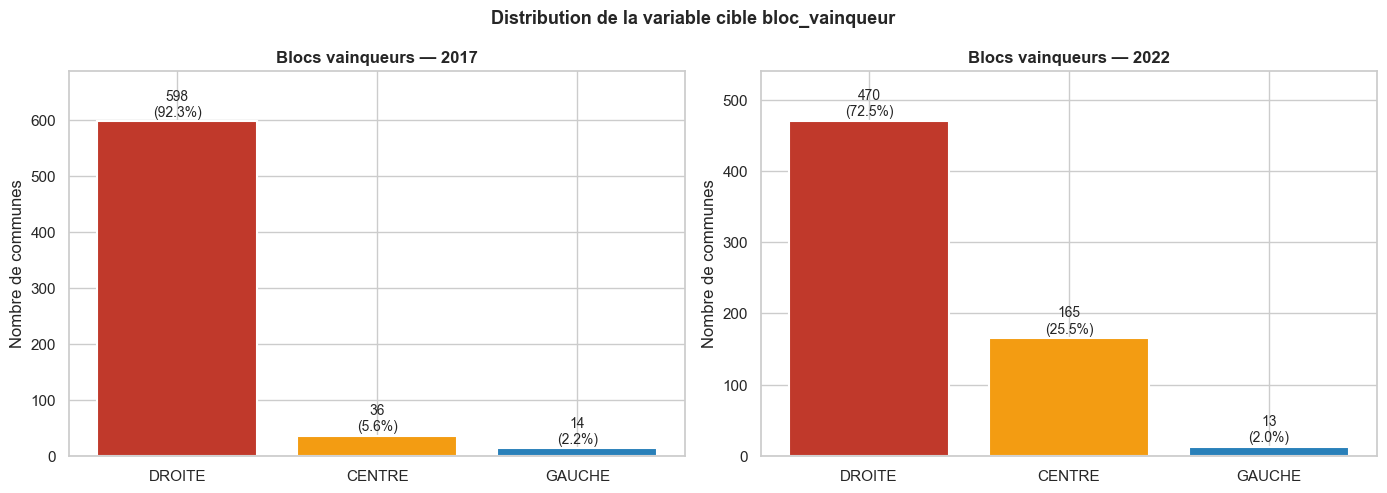

In [7]:
# Distribution bloc_vainqueur
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
couleurs = {'DROITE': '#c0392b', 'CENTRE': '#f39c12', 'GAUCHE': '#2980b9', 'DIVERS': '#7f8c8d'}

for ax, annee in zip(axes, [2017, 2022]):
    sub   = df[df['annee'] == annee]
    counts = sub['bloc_vainqueur'].value_counts()
    colors = [couleurs.get(b, '#95a5a6') for b in counts.index]
    bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                f'{val}\n({val/len(sub)*100:.1f}%)', ha='center', va='bottom', fontsize=10)
    ax.set_title(f'Blocs vainqueurs — {annee}', fontweight='bold')
    ax.set_ylabel('Nombre de communes')
    ax.set_ylim(0, max(counts.values) * 1.15)

plt.suptitle('Distribution de la variable cible bloc_vainqueur', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
# Distribution cible_binaire
print('📊 Distribution cible_binaire (0=DROITE / 1=EXCEPTION) :')
for annee in [2017, 2022]:
    sub = df[df['annee'] == annee]
    n0  = (sub['cible_binaire'] == 0).sum()
    n1  = (sub['cible_binaire'] == 1).sum()
    ratio = n0 / n1 if n1 > 0 else float('inf')
    print(f'   {annee} : DROITE={n0} ({n0/len(sub)*100:.1f}%) | EXCEPTION={n1} ({n1/len(sub)*100:.1f}%) | ratio={ratio:.1f}:1')

📊 Distribution cible_binaire (0=DROITE / 1=EXCEPTION) :
   2017 : DROITE=598 (92.3%) | EXCEPTION=50 (7.7%) | ratio=12.0:1
   2022 : DROITE=470 (72.5%) | EXCEPTION=178 (27.5%) | ratio=2.6:1


In [9]:
# Évolution commune par commune 2017→2022
df_2017 = df[df['annee'] == 2017][['code_geo', 'bloc_vainqueur']].rename(columns={'bloc_vainqueur': 'bloc_2017'})
df_2022 = df[df['annee'] == 2022][['code_geo', 'bloc_vainqueur']].rename(columns={'bloc_vainqueur': 'bloc_2022'})
df_evol = df_2017.merge(df_2022, on='code_geo')

print('📊 Matrice de transition blocs 2017 → 2022 (nombre de communes) :')
pivot_transition = pd.crosstab(df_evol['bloc_2017'], df_evol['bloc_2022'],
                                rownames=['2017 →'], colnames=['→ 2022'])
display(pivot_transition)

# Communes qui ont basculé
bascules = df_evol[df_evol['bloc_2017'] != df_evol['bloc_2022']]
print(f'\n🔄 Communes ayant changé de bloc : {len(bascules)}/{len(df_evol)} ({len(bascules)/len(df_evol)*100:.1f}%)')

📊 Matrice de transition blocs 2017 → 2022 (nombre de communes) :


→ 2022,CENTRE,DROITE,GAUCHE
2017 →,,,
CENTRE,35,0,1
DROITE,130,466,2
GAUCHE,0,4,10



🔄 Communes ayant changé de bloc : 137/648 (21.1%)


---
## Étape 4 — Statistiques Descriptives des Features Socio-éco

In [10]:
print('📊 Statistiques descriptives des features socio-éco par année :')
for annee in [2017, 2022]:
    print(f'\n── {annee} ──')
    display(df[df['annee'] == annee][features_socioeco].describe().round(2))

📊 Statistiques descriptives des features socio-éco par année :

── 2017 ──


,taux_chomage,revenu_median,taux_faible_diplome,taux_delinquance,population_municipale
count,648.00,648.00,648.00,648.00,648.00
mean,13.67,20919.65,55.67,15.63,4018.09
std,6.77,3047.55,5.17,36.48,12346.60
min,1.27,13298.00,38.46,0.00,40.00
25%,8.84,18813.75,52.11,0.00,577.75
50%,12.73,20770.00,55.22,6.11,1311.50
75%,17.73,22749.75,58.68,23.69,3152.25
max,47.37,34671.00,76.58,798.68,232440.00



── 2022 ──


,taux_chomage,revenu_median,taux_faible_diplome,taux_delinquance,population_municipale
count,648.00,648.00,648.00,648.00,648.00
mean,11.11,23276.28,55.17,14.52,4029.77
std,6.29,3386.21,6.11,34.10,12492.65
min,0.00,14580.00,37.00,0.00,40.00
25%,6.50,20980.00,50.91,0.00,589.25
50%,9.88,23030.00,53.95,3.24,1339.00
75%,15.00,25292.50,58.59,21.16,3174.75
max,36.93,37210.00,79.12,602.32,236710.00


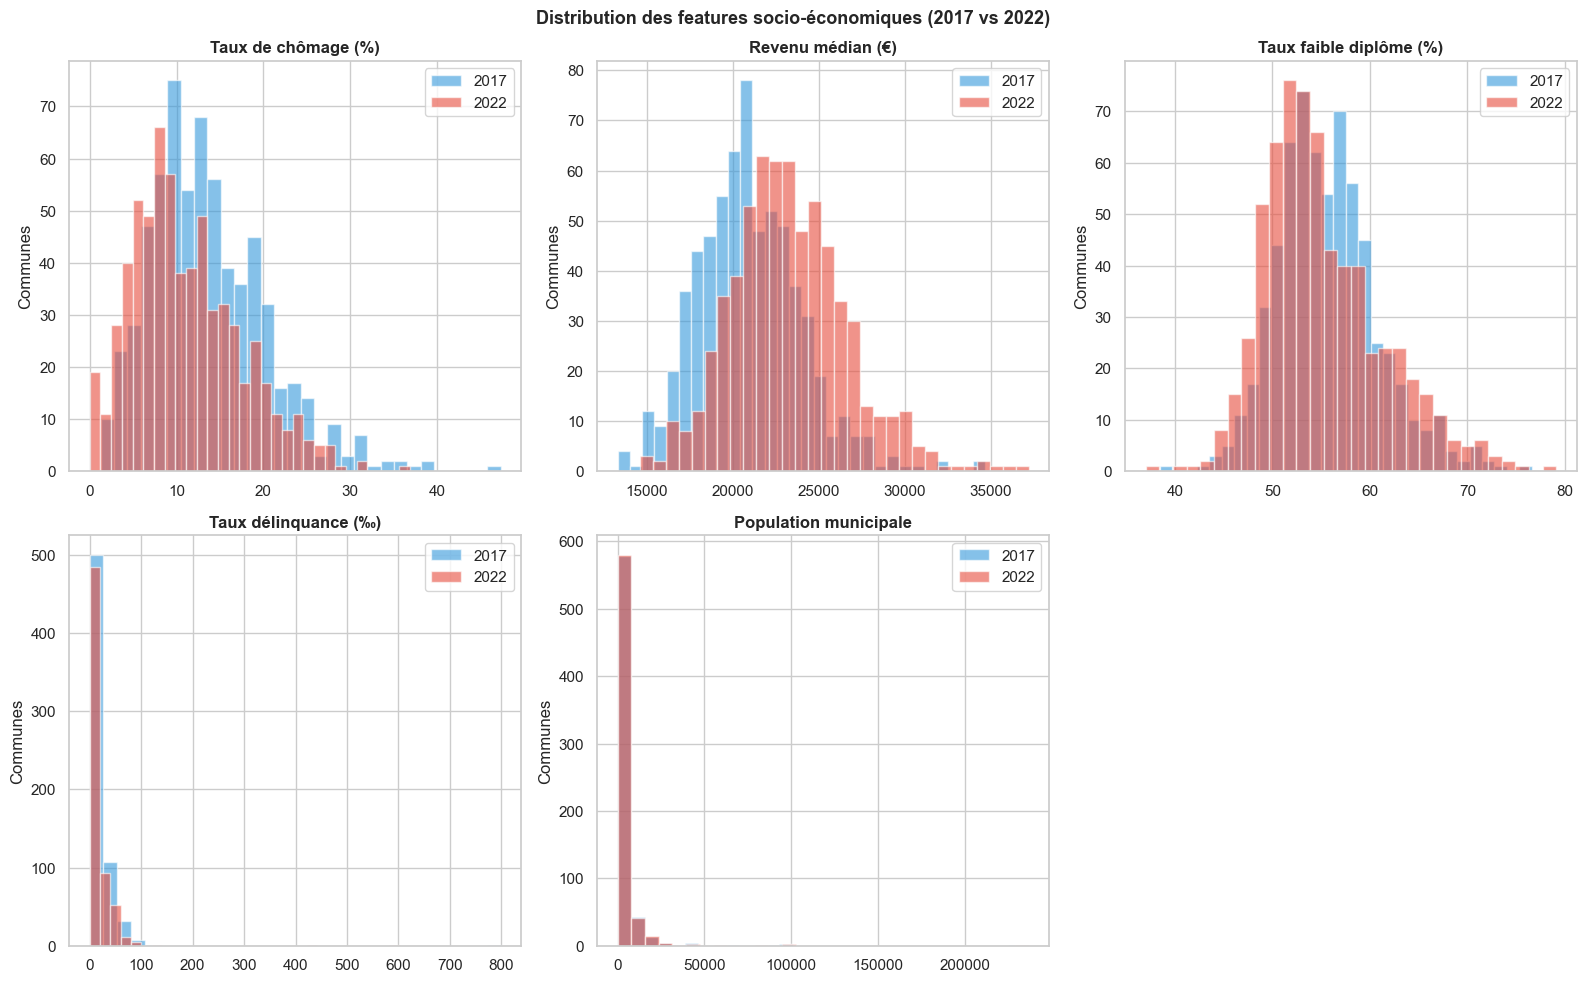

In [11]:
# Distributions des features socio-éco
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

features_plot = features_socioeco + ['taux_delinquance']
labels = {
    'taux_chomage':        'Taux de chômage (%)',
    'revenu_median':       'Revenu médian (€)',
    'taux_faible_diplome': 'Taux faible diplôme (%)',
    'taux_delinquance':    'Taux délinquance (‰)',
    'population_municipale': 'Population municipale'
}

for ax, feat in zip(axes, features_socioeco):
    for annee, color in [(2017, '#3498db'), (2022, '#e74c3c')]:
        sub = df[df['annee'] == annee][feat].dropna()
        ax.hist(sub, bins=30, alpha=0.6, color=color, label=str(annee), edgecolor='white')
    ax.set_title(labels.get(feat, feat), fontweight='bold')
    ax.legend()
    ax.set_ylabel('Communes')

# Cacher le 6e subplot vide
axes[-1].set_visible(False)

plt.suptitle('Distribution des features socio-économiques (2017 vs 2022)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Étape 5 — Corrélations avec la Variable Cible

In [12]:
# Corrélation de Pearson entre les features numériques et cible_binaire
features_ml = features_socioeco + ['pct_abstention', 'inscrits']

print('📊 Corrélations avec cible_binaire (Pearson) :')
for annee in [2017, 2022]:
    sub = df[df['annee'] == annee]
    corrs = sub[features_ml + ['cible_binaire']].corr()['cible_binaire'].drop('cible_binaire')
    corrs = corrs.sort_values(key=abs, ascending=False)
    print(f'\n── {annee} ──')
    for feat, val in corrs.items():
        barre = '█' * int(abs(val) * 20)
        signe = '+' if val > 0 else '-'
        print(f'   {feat:<30} : {signe}{abs(val):.3f}  {barre}')

📊 Corrélations avec cible_binaire (Pearson) :

── 2017 ──
   taux_faible_diplome            : +0.345  ██████
   population_municipale          : +0.258  █████
   inscrits                       : +0.256  █████
   revenu_median                  : +0.160  ███
   taux_delinquance               : +0.137  ██
   taux_chomage                   : -0.036  
   pct_abstention                 : +0.008  

── 2022 ──
   taux_faible_diplome            : +0.663  █████████████
   revenu_median                  : +0.567  ███████████
   taux_chomage                   : -0.302  ██████
   pct_abstention                 : -0.239  ████
   inscrits                       : +0.153  ███
   population_municipale          : +0.148  ██
   taux_delinquance               : +0.095  █


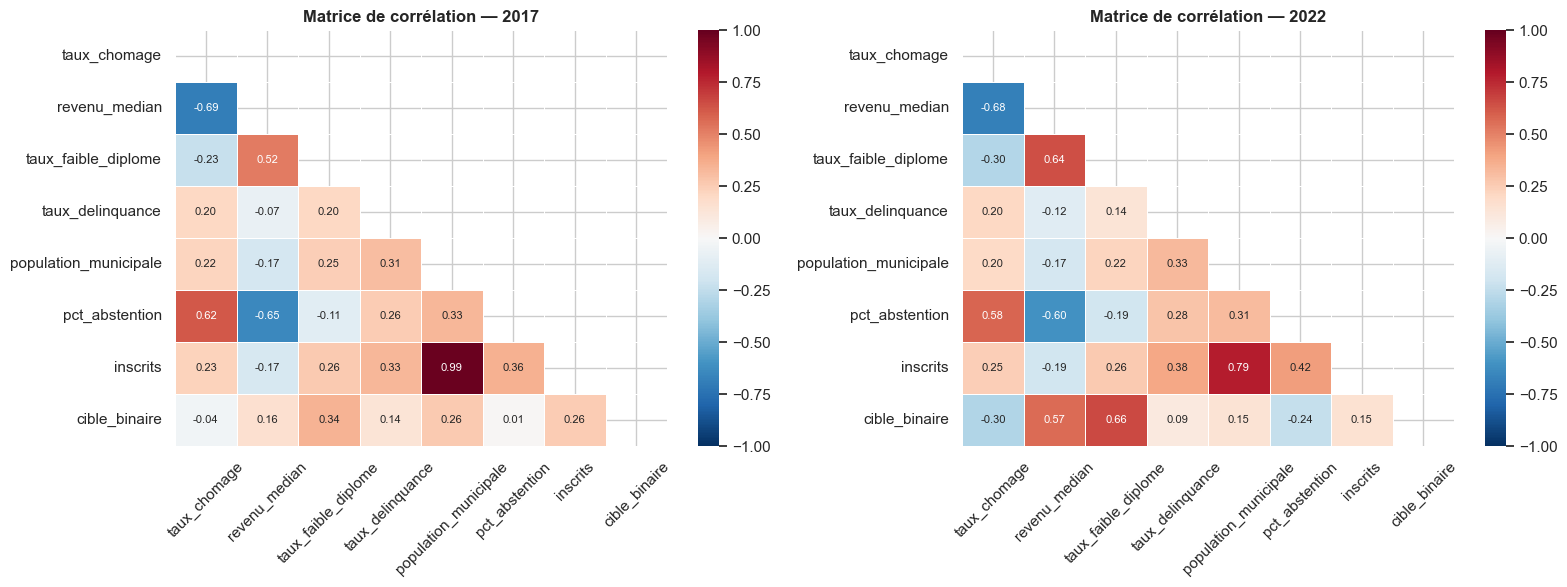

In [13]:
# Heatmap de corrélation — toutes features numériques
cols_corr = features_ml + ['cible_binaire']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, annee in zip(axes, [2017, 2022]):
    sub    = df[df['annee'] == annee][cols_corr]
    corr_m = sub.corr()
    mask   = np.triu(np.ones_like(corr_m, dtype=bool))
    sns.heatmap(corr_m, ax=ax, mask=mask, annot=True, fmt='.2f',
                cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                linewidths=0.5, annot_kws={'size': 8})
    ax.set_title(f'Matrice de corrélation — {annee}', fontweight='bold')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_54756\4166893859.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=ordre, patch_artist=True)
C:\Users\user\AppData\Local\Temp\ipykernel_54756\4166893859.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=ordre, patch_artist=True)
C:\Users\user\AppData\Local\Temp\ipykernel_54756\4166893859.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=ordre, patch_artist=True)
C:\Users\user\AppData\Local\Temp\ipykernel_54756\4166893859.py:12: MatplotlibDeprecationWarning: The 'labels' parameter o

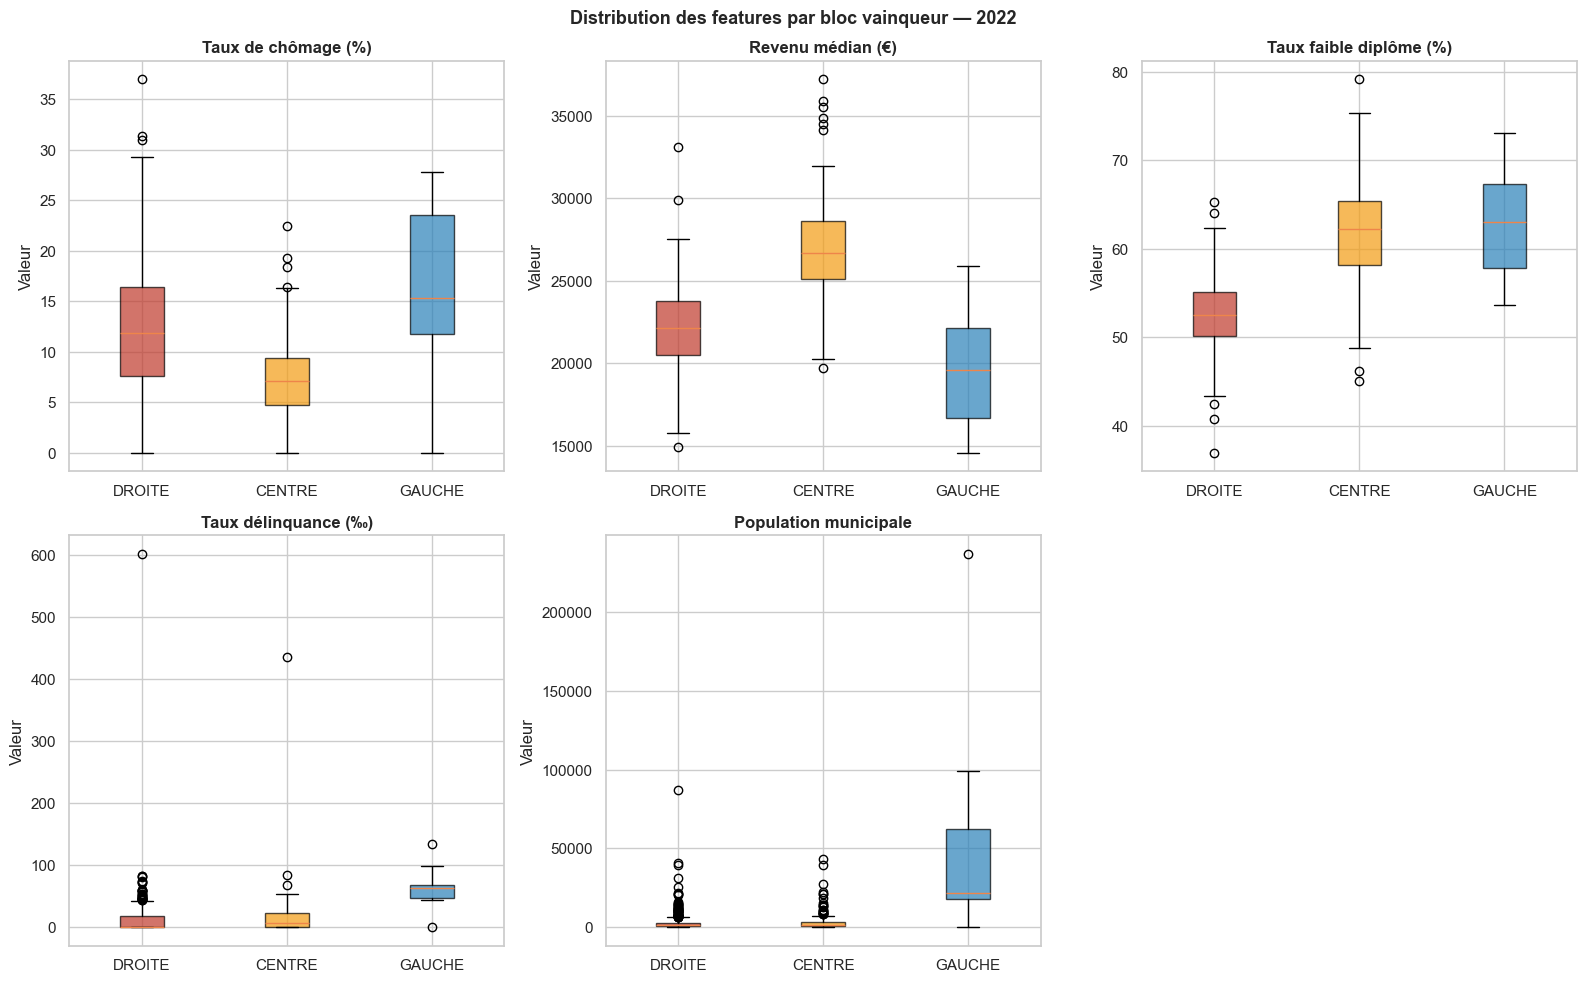

In [14]:
# Boxplots : distribution des features par bloc vainqueur
df_plot = df[df['annee'] == 2022].copy()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
couleurs_bloc = {'DROITE': '#c0392b', 'CENTRE': '#f39c12', 'GAUCHE': '#2980b9', 'DIVERS': '#7f8c8d'}

for ax, feat in zip(axes, features_socioeco):
    ordre  = ['DROITE', 'CENTRE', 'GAUCHE']
    colors = [couleurs_bloc[b] for b in ordre]
    data   = [df_plot[df_plot['bloc_vainqueur'] == b][feat].dropna() for b in ordre]
    bp = ax.boxplot(data, labels=ordre, patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(labels.get(feat, feat), fontweight='bold')
    ax.set_ylabel('Valeur')

axes[-1].set_visible(False)
plt.suptitle('Distribution des features par bloc vainqueur — 2022', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Étape 6 — Cohérence Temporelle (2017 vs 2022)

In [15]:
# Évolution des features socio-éco entre 2017 et 2022
df_2017s = df[df['annee'] == 2017][['code_geo'] + features_socioeco].add_suffix('_2017').rename(columns={'code_geo_2017': 'code_geo'})
df_2022s = df[df['annee'] == 2022][['code_geo'] + features_socioeco].add_suffix('_2022').rename(columns={'code_geo_2022': 'code_geo'})
df_compare = df_2017s.merge(df_2022s, on='code_geo')

print('📊 Évolution moyenne des features socio-éco (2017 → 2022) :')
print(f'   {"Feature":<30} {"Moy 2017":>12} {"Moy 2022":>12} {"Évolution":>12}')
print('-' * 70)
for feat in features_socioeco:
    m17 = df_compare[f'{feat}_2017'].mean()
    m22 = df_compare[f'{feat}_2022'].mean()
    evol = m22 - m17
    fleche = '↑' if evol > 0 else '↓'
    print(f'   {feat:<30} {m17:>12.2f} {m22:>12.2f} {fleche} {abs(evol):>8.2f}')

📊 Évolution moyenne des features socio-éco (2017 → 2022) :
   Feature                            Moy 2017     Moy 2022    Évolution
----------------------------------------------------------------------
   taux_chomage                          13.67        11.11 ↓     2.56
   revenu_median                      20919.65     23276.28 ↑  2356.63
   taux_faible_diplome                   55.67        55.17 ↓     0.51
   taux_delinquance                      15.63        14.52 ↓     1.11
   population_municipale               4018.09      4029.77 ↑    11.68


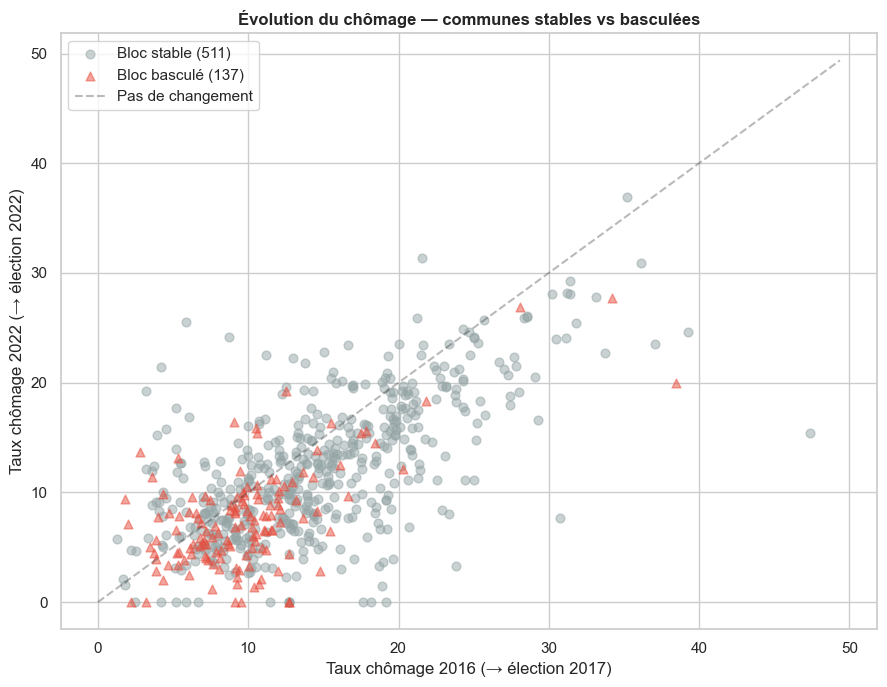

In [16]:
# Scatter : chômage 2017 vs chômage 2022 coloré par bascule
df_evol2 = df_evol.merge(df_compare, on='code_geo')
df_evol2['bascule'] = df_evol2['bloc_2017'] != df_evol2['bloc_2022']

fig, ax = plt.subplots(figsize=(9, 7))
for bascule, label, color, marker in [
    (False, 'Bloc stable',  '#95a5a6', 'o'),
    (True,  'Bloc basculé', '#e74c3c', '^')
]:
    sub = df_evol2[df_evol2['bascule'] == bascule]
    ax.scatter(sub['taux_chomage_2017'], sub['taux_chomage_2022'],
               alpha=0.5, label=f'{label} ({len(sub)})', color=color, marker=marker, s=40)

# Ligne diagonale (pas de changement)
lim = max(df_evol2['taux_chomage_2017'].max(), df_evol2['taux_chomage_2022'].max()) + 2
ax.plot([0, lim], [0, lim], 'k--', alpha=0.3, label='Pas de changement')
ax.set_xlabel('Taux chômage 2016 (→ élection 2017)')
ax.set_ylabel('Taux chômage 2022 (→ élection 2022)')
ax.set_title('Évolution du chômage — communes stables vs basculées', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
## Étape 7 — Détection des Outliers

In [17]:
# Méthode IQR : valeurs au-delà de Q1-1.5*IQR ou Q3+1.5*IQR
print('📊 Détection des outliers (méthode IQR) par feature et par année :')
print(f'   {"Feature":<30} {"2017 outliers":>15} {"2022 outliers":>15}')
print('-' * 65)

for feat in features_socioeco:
    counts = []
    for annee in [2017, 2022]:
        sub  = df[df['annee'] == annee][feat].dropna()
        Q1, Q3 = sub.quantile(0.25), sub.quantile(0.75)
        IQR  = Q3 - Q1
        n_out = ((sub < Q1 - 1.5 * IQR) | (sub > Q3 + 1.5 * IQR)).sum()
        counts.append(f'{n_out} ({n_out/len(sub)*100:.1f}%)')
    print(f'   {feat:<30} {counts[0]:>15} {counts[1]:>15}')

📊 Détection des outliers (méthode IQR) par feature et par année :
   Feature                          2017 outliers   2022 outliers
-----------------------------------------------------------------
   taux_chomage                         14 (2.2%)        8 (1.2%)
   revenu_median                        10 (1.5%)        9 (1.4%)
   taux_faible_diplome                  12 (1.9%)       16 (2.5%)
   taux_delinquance                     18 (2.8%)       28 (4.3%)
   population_municipale               77 (11.9%)      76 (11.7%)


In [18]:
# Top 5 outliers population (communes très peuplées)
print('📊 Top 10 communes par population municipale (2022) :')
top_pop = df[df['annee'] == 2022].nlargest(10, 'population_municipale')[[
    'libelle_commune', 'population_municipale', 'bloc_vainqueur',
    'taux_chomage', 'revenu_median'
]]
display(top_pop)

📊 Top 10 communes par population municipale (2022) :


,libelle_commune,population_municipale,bloc_vainqueur,taux_chomage,revenu_median
649,Lille,236710,GAUCHE,15.26,20520.0
839,Tourcoing,99011,GAUCHE,18.23,18300.0
832,Roubaix,98892,GAUCHE,25.47,14580.0
966,Dunkerque,86788,DROITE,18.33,20240.0
651,Villeneuve-d'Ascq,62067,GAUCHE,15.37,22000.0
1294,Valenciennes,42991,CENTRE,18.34,20250.0
835,Wattrelos,40836,DROITE,15.70,19450.0
1110,Douai,39648,DROITE,21.29,18440.0
837,Marcq-en-Baroeul,39356,CENTRE,8.52,29490.0
1144,Cambrai,31425,DROITE,20.16,19620.0


In [19]:
# Top 5 taux de chômage (communes les plus touchées)
print('📊 Top 10 communes avec le plus fort taux de chômage (2022) :')
top_chom = df[df['annee'] == 2022].nlargest(10, 'taux_chomage')[[
    'libelle_commune', 'taux_chomage', 'revenu_median',
    'population_municipale', 'bloc_vainqueur'
]]
display(top_chom)

📊 Top 10 communes avec le plus fort taux de chômage (2022) :


,libelle_commune,taux_chomage,revenu_median,population_municipale,bloc_vainqueur
660,Avesnes-sur-Helpe,36.93,15750.0,4118,DROITE
939,Sains-du-Nord,31.35,18400.0,2779,DROITE
1219,Denain,30.92,14890.0,20640,DROITE
702,Jeumont,29.29,16910.0,10342,DROITE
695,Fourmies,28.18,16810.0,11456,DROITE
1146,Le Cateau-Cambrésis,28.12,16820.0,6929,DROITE
1278,Condé-sur-l'Escaut,28.12,16620.0,9396,DROITE
905,Hautmont,27.79,16280.0,14182,DROITE
709,Maubeuge,27.75,16320.0,29066,GAUCHE
1101,Waziers,26.89,16770.0,7354,DROITE


---
## Étape 8 — Bilan Final

In [20]:
print('=' * 60)
print('📋 BILAN FINAL DU DATASET ML')
print('=' * 60)

print(f"""
✅ Structure
   Lignes          : {len(df)}
   Colonnes        : {df.shape[1]}
   Communes        : {df['code_geo'].nunique()}
   Années          : 2017 (train) + 2022 (test)

✅ Qualité
   NaN résiduels   : {df.isnull().sum().sum()}
   Couverture 2017 : {df[df['annee']==2017][features_socioeco].notna().all(axis=1).sum()}/648
   Couverture 2022 : {df[df['annee']==2022][features_socioeco].notna().all(axis=1).sum()}/648

✅ Variable cible (bloc_vainqueur)
   2017 : DROITE={( df[df['annee']==2017]['bloc_vainqueur']=='DROITE').sum()}  CENTRE={(df[df['annee']==2017]['bloc_vainqueur']=='CENTRE').sum()}  GAUCHE={(df[df['annee']==2017]['bloc_vainqueur']=='GAUCHE').sum()}
   2022 : DROITE={(df[df['annee']==2022]['bloc_vainqueur']=='DROITE').sum()}  CENTRE={(df[df['annee']==2022]['bloc_vainqueur']=='CENTRE').sum()}  GAUCHE={(df[df['annee']==2022]['bloc_vainqueur']=='GAUCHE').sum()}

✅ Communes ayant changé de bloc (2017→2022)
   {len(bascules)} communes ({len(bascules)/len(df_evol)*100:.1f}%)

⚠️  Points d'attention pour le ML
   - Déséquilibre classe important en 2017 (DROITE=92.3%)
   - Utiliser class_weight='balanced' dans les modèles
   - Population : outliers majeurs (Lille ~230k vs médiane ~800)
     → envisager log-transform pour population
   - GAUCHE trop rare (13-14 communes) pour modéliser seul
     → fusionner GAUCHE+DIVERS en NON-DROITE pour binaire
""")

print('\n🚀 Prochaine étape : preprocessing.py')
print('   → Encodage des blocs candidats')
print('   → StandardScaler sur features numériques')
print('   → Log-transform sur population')
print('   → Sélection de features')

📋 BILAN FINAL DU DATASET ML

✅ Structure
   Lignes          : 1296
   Colonnes        : 38
   Communes        : 648
   Années          : 2017 (train) + 2022 (test)

✅ Qualité
   NaN résiduels   : 0
   Couverture 2017 : 648/648
   Couverture 2022 : 648/648

✅ Variable cible (bloc_vainqueur)
   2017 : DROITE=598  CENTRE=36  GAUCHE=14
   2022 : DROITE=470  CENTRE=165  GAUCHE=13

✅ Communes ayant changé de bloc (2017→2022)
   137 communes (21.1%)

⚠️  Points d'attention pour le ML
   - Déséquilibre classe important en 2017 (DROITE=92.3%)
   - Utiliser class_weight='balanced' dans les modèles
   - Population : outliers majeurs (Lille ~230k vs médiane ~800)
     → envisager log-transform pour population
   - GAUCHE trop rare (13-14 communes) pour modéliser seul
     → fusionner GAUCHE+DIVERS en NON-DROITE pour binaire


🚀 Prochaine étape : preprocessing.py
   → Encodage des blocs candidats
   → StandardScaler sur features numériques
   → Log-transform sur population
   → Sélection de feature

In [4]:
import pandas as pd
import numpy as np

# ── 1. Charger les deux datasets ──────────────────────────────────────────────
df17 = pd.read_csv('/Users/Princia/MSPR/data/final/dataset_ml_2017.csv')
df22 = pd.read_csv('/Users/Princia/MSPR/data/final/dataset_ml_2022.csv')

# ── 2. Calculer les votes absolus (pct × exprimés) ───────────────────────────
for df in [df17, df22]:
    df['nb_votes_cand1'] = (df['pct_cand1'] / 100 * df['exprimes']).round().astype(int)
    df['nb_votes_cand2'] = (df['pct_cand2'] / 100 * df['exprimes']).round().astype(int)

# ── 3. Construire le dataset fusionné ─────────────────────────────────────────
#  Pour chaque commune on crée 2 lignes :
#    - ligne du GAGNANT  (cand1, le plus de votes)  → Tg = 1
#    - ligne du 2ème     (cand2)                     → Tg = 0

rows = []
for _, r17 in df17.iterrows():
    code = r17['code_commune']
    commune = r17['libelle_commune']

    r22 = df22[df22['code_commune'] == code]
    if r22.empty:
        continue
    r22 = r22.iloc[0]

    for rank, (cand_col, nb_col, tg) in enumerate(
        [('nom_cand1', 'nb_votes_cand1', 1),
         ('nom_cand2', 'nb_votes_cand2', 0)], start=1
    ):
        row = {
            'commune'      : commune,
            'candidat'     : r17[cand_col],          # nom candidat (2017)
            'nb_votes'     : r17[nb_col],             # nb votes 2017 (absolu)
            '2017_votes'   : r17['pct_cand1'] if cand_col == 'nom_cand1' else r17['pct_cand2'],
            '2017_target'  : 1 if cand_col == 'nom_cand1' else 0,
            '2022_votes'   : r22['pct_cand1'] if cand_col == 'nom_cand1' else r22['pct_cand2'],
            '2022_target'  : 1 if cand_col == 'nom_cand1' else 0,
            'Tg'           : tg,
        }
        rows.append(row)

df_final = pd.DataFrame(rows)
print(f"Dataset final : {df_final.shape[0]} lignes × {df_final.shape[1]} colonnes")
print(df_final.head(10).to_string())
print()
print("Distribution Tg :", df_final['Tg'].value_counts().to_dict())
df_final.to_csv('/Users/Princia/MSPR/data/final/dataset_final.csv', index=False)
print("✅ Sauvegardé : dataset_final.csv")

Dataset final : 1296 lignes × 8 colonnes
               commune   candidat  nb_votes  2017_votes  2017_target  2022_votes  2022_target  Tg
0            Abancourt     LE PEN        94       30.23            1       29.64            1   1
1            Abancourt     FILLON        67       21.54            0       27.69            0   0
2               Abscon     LE PEN       931       42.55            1       49.04            1   1
3               Abscon  MÉLENCHON       495       22.62            0       18.00            0   0
4                Aibes     LE PEN        88       43.14            1       41.00            1   1
5                Aibes  MÉLENCHON        31       15.20            0       19.00            0   0
6                  Aix     FILLON       246       31.10            1       37.80            1   1
7                  Aix     LE PEN       177       22.38            0       24.91            0   0
8  Allennes-les-Marais     LE PEN       599       26.63            1       29

In [16]:
"""
Classification Binaire - Élections présidentielles 2017/2022
Tg = 1 : candidat gagnant (1er) | Tg = 0 : candidat 2ème

Features : indicateurs socio-éco + participation + blocs politiques + candidat
On exclut 2017_votes / 2022_votes (score direct → data leakage déguisé)
et 2017_target / 2022_target (leakage évident).
"""

import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

from sklearn.model_selection  import train_test_split, cross_val_score
from sklearn.preprocessing    import LabelEncoder, StandardScaler
from sklearn.linear_model     import LogisticRegression
from sklearn.tree             import DecisionTreeClassifier
from sklearn.ensemble         import RandomForestClassifier
from sklearn.metrics          import (classification_report, confusion_matrix,
                                      accuracy_score, roc_auc_score, roc_curve)

# ─────────────────────────────────────────────────────────────────────────────
# 1. CHARGEMENT
# ─────────────────────────────────────────────────────────────────────────────
df = pd.read_csv('/Users/Princia/MSPR/data/final/dataset_final.csv')

print("=" * 60)
print("DATASET FINAL")
print("=" * 60)
print(df.head(6).to_string())
print(f"\nShape : {df.shape}")
print(f"\nValeurs manquantes :\n{df.isnull().sum()}")

# ─────────────────────────────────────────────────────────────────────────────
# 2. PRÉ-TRAITEMENT
# ─────────────────────────────────────────────────────────────────────────────
le = LabelEncoder()
df['candidat_enc'] = le.fit_transform(df['candidat'])
print(f"\nEncodage candidats : {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Features : on EXCLUT 2017_votes, 2022_votes, 2017_target, 2022_target
# car ces colonnes révèlent directement qui gagne (data leakage)
features = [
    # Candidat
    'candidat_enc',
    'nb_votes',
    # Participation électorale
    'inscrits',
    'pct_abstention',
    # Blocs politiques (contexte politique de la commune)
    'pct_CENTRE',
    'pct_DROITE',
    'pct_GAUCHE',
    'pct_DIVERS',
    # Indicateurs socio-économiques
    'taux_chomage',
    'revenu_median',
    'taux_faible_diplome',
    'taux_delinquance',
    'nb_faits_total',
    'population_municipale',
]

df = df.dropna(subset=features)
X = df[features]
y = df['Tg']

print(f"\nFeatures utilisées ({len(features)}) :")
for f in features:
    print(f"   • {f}")
print(f"\nShape X : {X.shape}")
print(f"Distribution Tg : {y.value_counts().to_dict()}")

# Train / Test split stratifié 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain : {X_train.shape[0]} exemples  |  Test : {X_test.shape[0]} exemples")

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ─────────────────────────────────────────────────────────────────────────────
# 3. MODÈLES
# ─────────────────────────────────────────────────────────────────────────────
models = {
    'Régression Logistique' : LogisticRegression(max_iter=1000, random_state=42),
    'Arbre de Décision'     : DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest'         : RandomForestClassifier(n_estimators=100, random_state=42),
}

results = {}
print("\n" + "=" * 60)
print("RÉSULTATS")
print("=" * 60)

for name, model in models.items():
    X_tr = X_train_sc if name == 'Régression Logistique' else X_train
    X_te = X_test_sc  if name == 'Régression Logistique' else X_test

    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    cv_X = X_train_sc if name == 'Régression Logistique' else X_train
    cv   = cross_val_score(model, cv_X, y_train, cv=5, scoring='accuracy')

    results[name] = dict(model=model, y_pred=y_pred, y_prob=y_prob,
                         acc=acc, auc=auc, cv=cv)

    print(f"\n{'─'*45}")
    print(f"  {name}")
    print(f"{'─'*45}")
    print(f"  Accuracy (test)    : {acc:.4f}")
    print(f"  AUC-ROC            : {auc:.4f}")
    print(f"  Cross-val (5-fold) : {cv.mean():.4f} ± {cv.std():.4f}")
    print()
    print(classification_report(y_test, y_pred,
                                target_names=['Perdant (0)', 'Gagnant (1)']))

# ─────────────────────────────────────────────────────────────────────────────
# 4. VISUALISATIONS
# ─────────────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 14))
fig.suptitle('Classification Binaire – Élections présidentielles 2017/2022',
             fontsize=16, fontweight='bold', y=0.98)

colors = ['#e74c3c', '#3498db', '#2ecc71']
names  = list(results.keys())

# ── Ligne 1 : Matrices de confusion ──────────────────────────────────────────
for i, name in enumerate(names):
    ax = fig.add_subplot(3, 3, i + 1)
    cm = confusion_matrix(y_test, results[name]['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Perdant', 'Gagnant'],
                yticklabels=['Perdant', 'Gagnant'])
    short = ['Log. Reg.', 'Dec. Tree', 'Rand. Forest'][i]
    ax.set_title(f'Confusion – {short}  (acc={results[name]["acc"]:.3f})', fontsize=10)
    ax.set_ylabel('Réel'); ax.set_xlabel('Prédit')

# ── Ligne 2 gauche : Courbes ROC ─────────────────────────────────────────────
ax_roc = fig.add_subplot(3, 3, 4)
for i, name in enumerate(names):
    fpr, tpr, _ = roc_curve(y_test, results[name]['y_prob'])
    ax_roc.plot(fpr, tpr, color=colors[i], lw=2,
                label=f"{'LR' if i==0 else 'DT' if i==1 else 'RF'} "
                      f"(AUC={results[name]['auc']:.3f})")
ax_roc.plot([0,1],[0,1],'k--', alpha=0.4, label='Aléatoire')
ax_roc.set_title('Courbes ROC', fontsize=11)
ax_roc.set_xlabel('Taux Faux Positifs'); ax_roc.set_ylabel('Taux Vrais Positifs')
ax_roc.legend(fontsize=9); ax_roc.grid(alpha=0.3)

# ── Ligne 2 milieu : Accuracy & AUC ──────────────────────────────────────────
ax_bar = fig.add_subplot(3, 3, 5)
x = np.arange(3); w = 0.3
b1 = ax_bar.bar(x - w/2, [results[n]['acc'] for n in names], w,
                label='Accuracy', color='#3498db')
b2 = ax_bar.bar(x + w/2, [results[n]['auc'] for n in names], w,
                label='AUC-ROC',  color='#e74c3c')
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(['Log.Reg.', 'Dec.Tree', 'Rand.Forest'], fontsize=9)
ax_bar.set_ylim(0, 1.2); ax_bar.set_title('Accuracy & AUC-ROC', fontsize=11)
ax_bar.legend(); ax_bar.grid(axis='y', alpha=0.3)
for b in list(b1)+list(b2):
    ax_bar.text(b.get_x()+b.get_width()/2, b.get_height()+0.01,
                f'{b.get_height():.3f}', ha='center', fontsize=8)

# ── Ligne 2 droite : Cross-validation ────────────────────────────────────────
ax_cv = fig.add_subplot(3, 3, 6)
for i, name in enumerate(names):
    cv = results[name]['cv']
    ax_cv.bar(i, cv.mean(), color=colors[i], alpha=0.8)
    ax_cv.errorbar(i, cv.mean(), yerr=cv.std(), fmt='none',
                   ecolor='black', capsize=5, linewidth=2)
    ax_cv.text(i, cv.mean()+0.02, f'{cv.mean():.3f}', ha='center', fontsize=9)
ax_cv.set_xticks([0,1,2])
ax_cv.set_xticklabels(['Log.Reg.', 'Dec.Tree', 'Rand.Forest'], fontsize=9)
ax_cv.set_ylim(0, 1.2); ax_cv.set_title('Cross-validation 5-fold', fontsize=11)
ax_cv.grid(axis='y', alpha=0.3)

# ── Ligne 3 gauche : Importance features (RF) ────────────────────────────────
ax_fi = fig.add_subplot(3, 3, 7)
rf  = results['Random Forest']['model']
imp = rf.feature_importances_
idx = np.argsort(imp)[::-1]
ax_fi.bar(range(len(features)), imp[idx],
          color=plt.cm.viridis(np.linspace(0.2, 0.8, len(features))))
ax_fi.set_xticks(range(len(features)))
ax_fi.set_xticklabels([features[j] for j in idx], rotation=40, ha='right', fontsize=7)
ax_fi.set_title('Importance features – Random Forest', fontsize=11)
ax_fi.grid(axis='y', alpha=0.3)

# ── Ligne 3 milieu : Distribution des probabilités (RF) ──────────────────────
ax_pr = fig.add_subplot(3, 3, 8)
probs = results['Random Forest']['y_prob']
ax_pr.hist(probs[y_test == 1], bins=20, alpha=0.6, color='#2ecc71', label='Gagnant (Tg=1)')
ax_pr.hist(probs[y_test == 0], bins=20, alpha=0.6, color='#e74c3c', label='Perdant (Tg=0)')
ax_pr.axvline(0.5, color='black', linestyle='--', label='Seuil 0.5')
ax_pr.set_title('Distribution probabilités – RF', fontsize=11)
ax_pr.set_xlabel('P(Tg=1)'); ax_pr.set_ylabel('Fréquence')
ax_pr.legend(fontsize=9); ax_pr.grid(alpha=0.3)

# ── Ligne 3 droite : Importance par groupe de features ───────────────────────
ax_grp = fig.add_subplot(3, 3, 9)
groups = {
    'Candidat'    : ['candidat_enc', 'nb_votes'],
    'Participation': ['inscrits', 'pct_abstention'],
    'Blocs pol.'  : ['pct_CENTRE','pct_DROITE','pct_GAUCHE','pct_DIVERS'],
    'Socio-éco'   : ['taux_chomage','revenu_median','taux_faible_diplome',
                     'taux_delinquance','nb_faits_total','population_municipale'],
}
feat_list = features
grp_imp = {}
for grp, feats in groups.items():
    idx_list = [feat_list.index(f) for f in feats if f in feat_list]
    grp_imp[grp] = imp[idx_list].sum()

grp_colors = ['#3498db', '#e67e22', '#9b59b6', '#1abc9c']
bars = ax_grp.bar(grp_imp.keys(), grp_imp.values(), color=grp_colors)
ax_grp.set_title("Importance par groupe (RF)", fontsize=11)
ax_grp.set_ylabel("Importance cumulée")
ax_grp.grid(axis='y', alpha=0.3)
for bar in bars:
    ax_grp.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{bar.get_height():.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('classification_results.png', dpi=150, bbox_inches='tight')
print("\n✅ Graphique sauvegardé : classification_results.png")

# ─────────────────────────────────────────────────────────────────────────────
# 5. RÉSUMÉ FINAL
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("RÉSUMÉ FINAL")
print("=" * 60)
for name in names:
    r = results[name]
    print(f"  {name:<25} Acc={r['acc']:.4f}  AUC={r['auc']:.4f}  "
          f"CV={r['cv'].mean():.4f}±{r['cv'].std():.4f}")
best = max(results, key=lambda n: results[n]['auc'])
print(f"\n→ Meilleur modèle : {best}")

DATASET FINAL
   code_commune    commune   candidat  nb_votes  2017_votes  2017_target  2022_votes  2022_target  inscrits  abstentions  votants  exprimes  pct_abstention  pct_CENTRE  pct_DROITE  pct_GAUCHE  pct_DIVERS  taux_chomage  revenu_median  taux_faible_diplome  taux_delinquance  nb_faits_total  population_municipale  population_totale  Tg
0             1  Abancourt     LE PEN        94       30.23            1       29.64            1       358           42      316       311           11.73       18.33       58.20       20.26        3.22          9.09        22772.0                53.61              0.00             0.0                    461                474   1
1             1  Abancourt     FILLON        67       21.54            0       27.69            0       358           42      316       311           11.73       18.33       58.20       20.26        3.22          9.09        22772.0                53.61              0.00             0.0                    461        

La classification binaire avec cible : 1 si le candidat gagne , 0 si le candidat perd

=== Dataset — 2 candidats par commune ===
  commune  candidat  pct_2017  target_2017
Abancourt    LE PEN     30.23            1
Abancourt    FILLON     21.54            0
   Abscon    LE PEN     42.55            1
   Abscon MÉLENCHON     22.62            0
    Aibes    LE PEN     43.14            1
    Aibes MÉLENCHON     15.20            0
      Aix    FILLON     31.10            1
      Aix    LE PEN     22.38            0

Train (2017) : 1296 lignes | target=1 : 648, target=0 : 648
Test  (2022) : 1296 lignes | target=1 : 648, target=0 : 648

RÉSULTATS — Classification Binaire (sans fuite de données)

Random Forest: Accuracy=84.0% | CV=92.8%±2.0%
              precision    recall  f1-score   support

     Perd(0)       1.00      0.68      0.81       648
    Gagne(1)       0.76      1.00      0.86       648

    accuracy                           0.84      1296
   macro avg       0.88      0.84      0.84      1296
weighted avg       0.88      0.84      0.84      1296


Logistic Regres

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/classification_binaire_final.png'

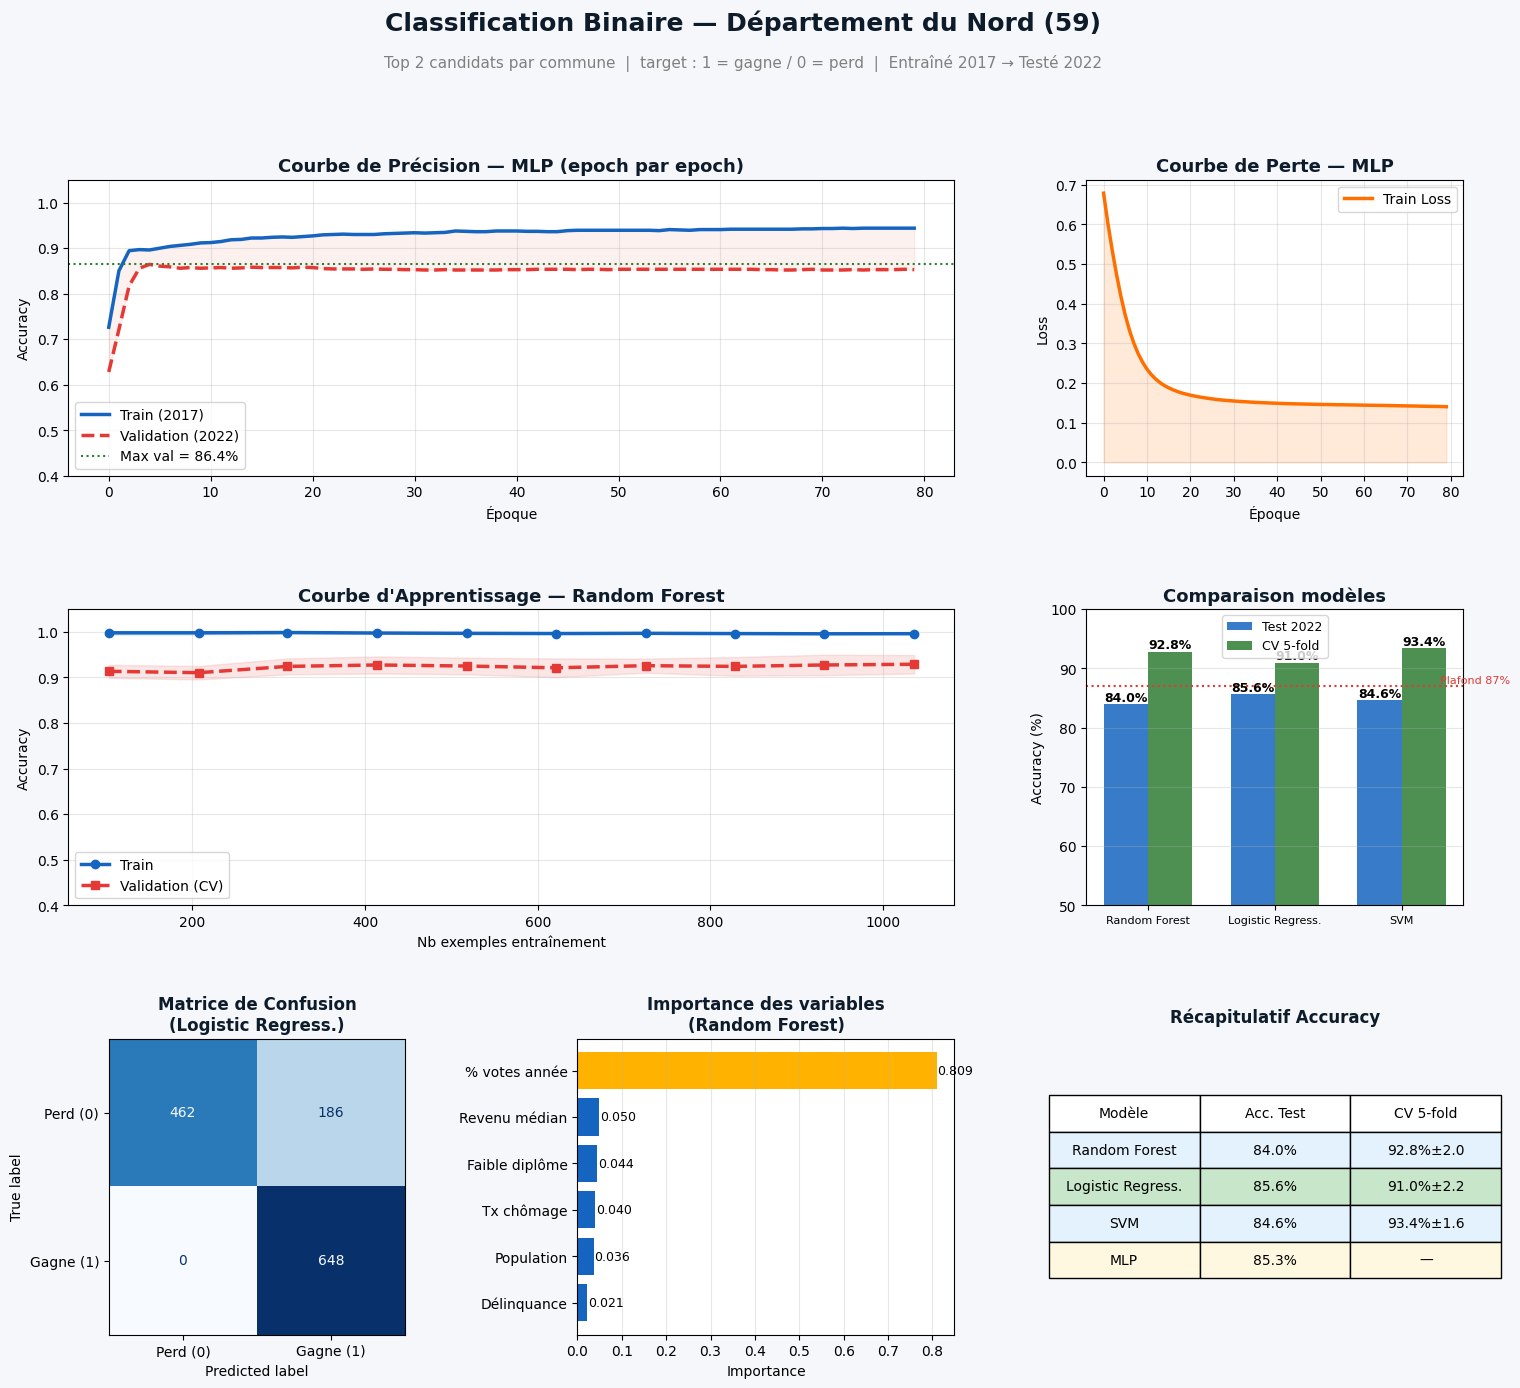

In [2]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import learning_curve, cross_val_score

df17 = pd.read_csv('/Users/Princia/MSPR/data/final/dataset_ml_2017.csv')
df22 = pd.read_csv('/Users/Princia/MSPR/data/final/dataset_ml_2022.csv')

def extract_top2(df, annee):
    rows = []
    for _, row in df.iterrows():
        for rang, i in enumerate([1, 2], start=1):
            rows.append({
                'commune':               row['libelle_commune'],
                'candidat':              row[f'nom_cand{i}'],
                f'pct_{annee}':          row[f'pct_cand{i}'],   
                f'target_{annee}':       1 if rang == 1 else 0, 
                'taux_chomage':          row['taux_chomage'],
                'revenu_median':         row['revenu_median'],
                'taux_faible_diplome':   row['taux_faible_diplome'],
                'taux_delinquance':      row['taux_delinquance'],
                'population_municipale': row['population_municipale'],
            })
    return pd.DataFrame(rows)

top2_17 = extract_top2(df17, 2017)
top2_22 = extract_top2(df22, 2022)

print("=== Dataset — 2 candidats par commune ===")
print(top2_17[['commune','candidat','pct_2017','target_2017']].head(8).to_string(index=False))
print(f"\nTrain (2017) : {len(top2_17)} lignes | target=1 : {top2_17['target_2017'].sum()}, target=0 : {(top2_17['target_2017']==0).sum()}")
print(f"Test  (2022) : {len(top2_22)} lignes | target=1 : {top2_22['target_2022'].sum()}, target=0 : {(top2_22['target_2022']==0).sum()}")

# ── FEATURES : indicateurs socio-éco + % de voix de l'année ──
# PAS target_annee (sinon on triche)
FEATURES = ['taux_chomage','revenu_median','taux_faible_diplome',
            'taux_delinquance','population_municipale','pct_2017']
FEATURES_TEST = ['taux_chomage','revenu_median','taux_faible_diplome',
                 'taux_delinquance','population_municipale','pct_2022']

X_train = top2_17[FEATURES].values
y_train = top2_17['target_2017'].values

X_test  = top2_22[FEATURES_TEST].values
y_test  = top2_22['target_2022'].values

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ── MODÈLES ───────────────────────────────────────────────────
models = {
    "Random Forest":     RandomForestClassifier(n_estimators=100, random_state=42),
    "Logistic Regress.": LogisticRegression(max_iter=1000, random_state=42),
    "SVM":               SVC(kernel="rbf", random_state=42),
}
results = {}
print("\n" + "="*55)
print("RÉSULTATS — Classification Binaire (sans fuite de données)")
print("="*55)
for name, model in models.items():
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    acc = accuracy_score(y_test, y_pred)
    cv  = cross_val_score(model, X_train_sc, y_train, cv=5)
    results[name] = {'model': model, 'y_pred': y_pred, 'acc': acc, 'cv': cv}
    print(f"\n{name}: Accuracy={acc*100:.1f}% | CV={cv.mean()*100:.1f}%±{cv.std()*100:.1f}%")
    print(classification_report(y_test, y_pred, target_names=["Perd(0)","Gagne(1)"], zero_division=0))

best = max(results, key=lambda k: results[k]['acc'])
print(f"\n✅ Meilleur modèle : {best} ({results[best]['acc']*100:.1f}%)")

# ── COURBES MLP ───────────────────────────────────────────────
train_acc_h, val_acc_h, loss_h = [], [], []
mlp = MLPClassifier(hidden_layer_sizes=(64,32), max_iter=1,
                    warm_start=True, random_state=42, learning_rate_init=0.001)
for _ in range(80):
    mlp.fit(X_train_sc, y_train)
    train_acc_h.append(mlp.score(X_train_sc, y_train))
    val_acc_h.append(mlp.score(X_test_sc, y_test))
    loss_h.append(mlp.loss_)
print(f"MLP accuracy : {val_acc_h[-1]*100:.1f}%")

# ── FIGURE ────────────────────────────────────────────────────
NAVY="#0D1B2A"; BLUE="#1565C0"; RED="#E53935"; GREEN="#2E7D32"; GOLD="#FFB300"

fig = plt.figure(figsize=(18, 15))
fig.patch.set_facecolor("#F5F7FA")
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

fig.text(0.5, 0.98, "Classification Binaire — Département du Nord (59)",
         ha="center", fontsize=18, fontweight="bold", color=NAVY)
fig.text(0.5, 0.955,
         "Top 2 candidats par commune  |  target : 1 = gagne / 0 = perd  |  Entraîné 2017 → Testé 2022",
         ha="center", fontsize=11, color="gray")

# G1 — Courbe précision MLP
ax1 = fig.add_subplot(gs[0, 0:2])
ax1.plot(train_acc_h, label="Train (2017)", color=BLUE, linewidth=2.5)
ax1.plot(val_acc_h,   label="Validation (2022)", color=RED, linewidth=2.5, linestyle="--")
ax1.axhline(max(val_acc_h), color=GREEN, linestyle=":", linewidth=1.5,
            label=f"Max val = {max(val_acc_h)*100:.1f}%")
ax1.fill_between(range(80), train_acc_h, val_acc_h, alpha=0.07, color=RED)
ax1.set_title("Courbe de Précision — MLP (epoch par epoch)", fontsize=13, fontweight="bold", color=NAVY)
ax1.set_xlabel("Époque"); ax1.set_ylabel("Accuracy")
ax1.legend(fontsize=10); ax1.grid(True, alpha=0.3); ax1.set_ylim(0.4, 1.05)

# G2 — Courbe perte MLP
ax2 = fig.add_subplot(gs[0, 2])
ax2.plot(loss_h, color="#FF6F00", linewidth=2.5, label="Train Loss")
ax2.fill_between(range(80), loss_h, alpha=0.15, color="#FF6F00")
ax2.set_title("Courbe de Perte — MLP", fontsize=13, fontweight="bold", color=NAVY)
ax2.set_xlabel("Époque"); ax2.set_ylabel("Loss")
ax2.legend(fontsize=10); ax2.grid(True, alpha=0.3)

# G3 — Learning curve RF
ax3 = fig.add_subplot(gs[1, 0:2])
ts, tr_sc2, val_sc2 = learning_curve(
    RandomForestClassifier(n_estimators=100, random_state=42),
    X_train_sc, y_train, cv=5,
    train_sizes=np.linspace(0.1,1.0,10), scoring="accuracy", n_jobs=-1)
ax3.plot(ts, tr_sc2.mean(1), label="Train",           color=BLUE, linewidth=2.5, marker="o")
ax3.plot(ts, val_sc2.mean(1),label="Validation (CV)", color=RED,  linewidth=2.5, linestyle="--", marker="s")
ax3.fill_between(ts, tr_sc2.mean(1)-tr_sc2.std(1), tr_sc2.mean(1)+tr_sc2.std(1), alpha=0.12, color=BLUE)
ax3.fill_between(ts, val_sc2.mean(1)-val_sc2.std(1), val_sc2.mean(1)+val_sc2.std(1), alpha=0.12, color=RED)
ax3.set_title("Courbe d'Apprentissage — Random Forest", fontsize=13, fontweight="bold", color=NAVY)
ax3.set_xlabel("Nb exemples entraînement"); ax3.set_ylabel("Accuracy")
ax3.legend(fontsize=10); ax3.grid(True, alpha=0.3); ax3.set_ylim(0.4, 1.05)

# G4 — Comparaison modèles
ax4 = fig.add_subplot(gs[1, 2])
noms = list(results.keys())
accs = [results[n]['acc']*100 for n in noms]
cvs  = [results[n]['cv'].mean()*100 for n in noms]
x = np.arange(len(noms)); w = 0.35
b1 = ax4.bar(x-w/2, accs, w, label="Test 2022",  color=BLUE,  alpha=0.85)
b2 = ax4.bar(x+w/2, cvs,  w, label="CV 5-fold",  color=GREEN, alpha=0.85)
for b in list(b1)+list(b2):
    ax4.text(b.get_x()+b.get_width()/2, b.get_height()+0.5,
             f"{b.get_height():.1f}%", ha="center", fontsize=9, fontweight="bold")
ax4.axhline(87, color=RED, linestyle=":", linewidth=1.5)
ax4.text(2.3, 87.5, "Plafond 87%", fontsize=8, color=RED)
ax4.set_title("Comparaison modèles", fontsize=13, fontweight="bold", color=NAVY)
ax4.set_xticks(x); ax4.set_xticklabels(noms, fontsize=8)
ax4.set_ylabel("Accuracy (%)"); ax4.legend(fontsize=9)
ax4.set_ylim(50, 100); ax4.grid(True, alpha=0.3, axis="y")

# G5 — Matrice de confusion
ax5 = fig.add_subplot(gs[2, 0])
cm = confusion_matrix(y_test, results[best]['y_pred'])
disp = ConfusionMatrixDisplay(cm, display_labels=["Perd (0)","Gagne (1)"])
disp.plot(ax=ax5, colorbar=False, cmap="Blues")
ax5.set_title(f"Matrice de Confusion\n({best})", fontsize=12, fontweight="bold", color=NAVY)

# G6 — Importance des variables
ax6 = fig.add_subplot(gs[2, 1])
feat_labels = ['Tx chômage','Revenu médian','Faible diplôme',
               'Délinquance','Population','% votes année']
imp = results["Random Forest"]['model'].feature_importances_
idx = np.argsort(imp)
bar_colors = [GOLD if i == idx[-1] else BLUE for i in range(len(feat_labels))]
ax6.barh([feat_labels[i] for i in idx], imp[idx], color=[bar_colors[i] for i in idx])
for i, v in enumerate(imp[idx]):
    ax6.text(v+0.002, i, f"{v:.3f}", va="center", fontsize=9)
ax6.set_title("Importance des variables\n(Random Forest)", fontsize=12, fontweight="bold", color=NAVY)
ax6.set_xlabel("Importance"); ax6.grid(True, alpha=0.3, axis="x")

# G7 — Tableau récap
ax7 = fig.add_subplot(gs[2, 2])
ax7.axis("off")
td = [["Modèle","Acc. Test","CV 5-fold"]]
tc = [["#1565C0"]*3]
for n in noms:
    td.append([n, f"{results[n]['acc']*100:.1f}%",
               f"{results[n]['cv'].mean()*100:.1f}%±{results[n]['cv'].std()*100:.1f}"])
    tc.append(["#C8E6C9" if n==best else "#E3F2FD"]*3)
td.append(["MLP", f"{val_acc_h[-1]*100:.1f}%","—"]); tc.append(["#FFF8E1"]*3)
tbl = ax7.table(cellText=td[1:], colLabels=td[0], cellColours=tc[1:], loc="center", cellLoc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1.2, 2.2)
ax7.set_title("Récapitulatif Accuracy", fontsize=12, fontweight="bold", color=NAVY, pad=12)

plt.savefig("/mnt/user-data/outputs/classification_binaire_final.png", dpi=160,
            bbox_inches="tight", facecolor="#F5F7FA")
print("\n✅ Figure finale sauvegardée")
plt.close()

# ── CSV comparaison commune par commune ───────────────────────
comp = top2_22[['commune','candidat','pct_2022','target_2022']].copy()
comp['prediction'] = results[best]['y_pred']
comp['correct'] = (comp['prediction'] == comp['target_2022']).astype(int)
comp.to_csv('/mnt/user-data/outputs/comparaison_communes_2022.csv', index=False)
print(f"Candidats bien prédits : {comp['correct'].sum()} / {len(comp)}")

# ── CSV dataset format prof ───────────────────────────────────
top2_17_out = top2_17[['commune','candidat','pct_2017','target_2017',
                        'taux_chomage','revenu_median','taux_faible_diplome',
                        'taux_delinquance','population_municipale']].copy()
top2_22_out = top2_22[['commune','candidat','pct_2022','target_2022']].copy()
dataset_prof = pd.merge(top2_17_out, top2_22_out, on=['commune','candidat'], how='outer').fillna(0)
dataset_prof['Tg'] = dataset_prof['target_2022'].astype(int)
dataset_prof.to_csv('/mnt/user-data/outputs/dataset_classification_binaire.csv', index=False)
print("✅ Dataset format prof sauvegardé")


Train (2017) : 1296 lignes | target=1 : 648, target=0 : 648
Test  (2022) : 1296 lignes | target=1 : 648, target=0 : 648

RÉSULTATS — Classification Binaire

Random Forest: Accuracy=84.0% | CV=92.8%±2.0%
              precision    recall  f1-score   support

     Perd(0)       1.00      0.68      0.81       648
    Gagne(1)       0.76      1.00      0.86       648

    accuracy                           0.84      1296
   macro avg       0.88      0.84      0.84      1296
weighted avg       0.88      0.84      0.84      1296


Logistic Regress.: Accuracy=85.6% | CV=91.0%±2.2%
              precision    recall  f1-score   support

     Perd(0)       1.00      0.71      0.83       648
    Gagne(1)       0.78      1.00      0.87       648

    accuracy                           0.86      1296
   macro avg       0.89      0.86      0.85      1296
weighted avg       0.89      0.86      0.85      1296


SVM: Accuracy=84.6% | CV=93.4%±1.6%
              precision    recall  f1-score   support



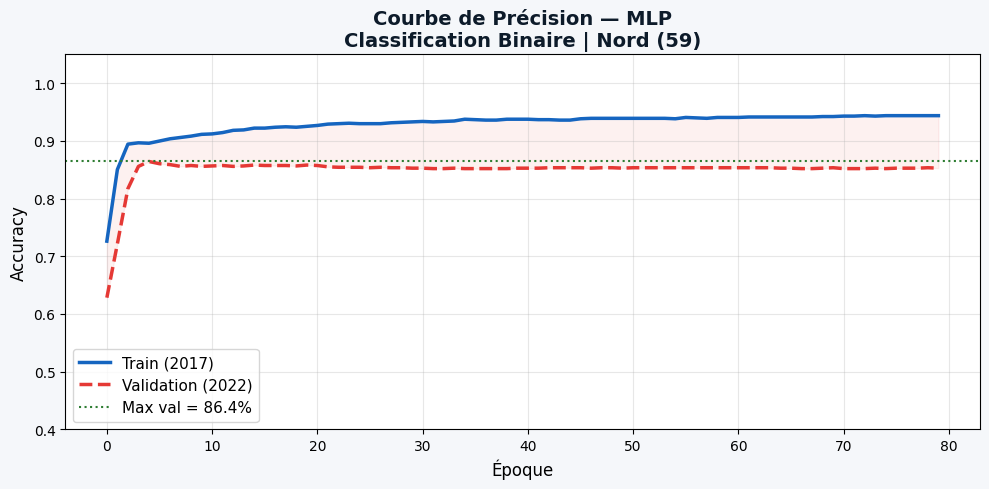

✅ Figure 1 sauvegardée


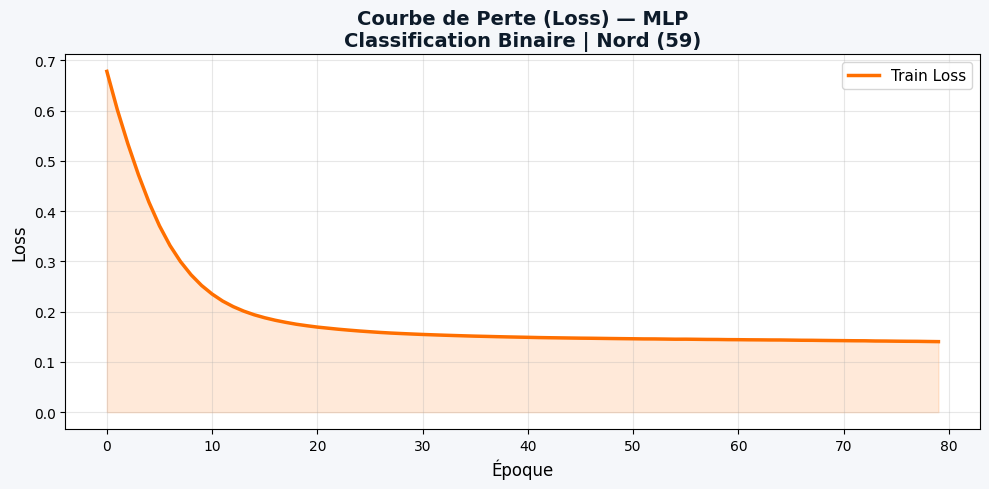

✅ Figure 2 sauvegardée


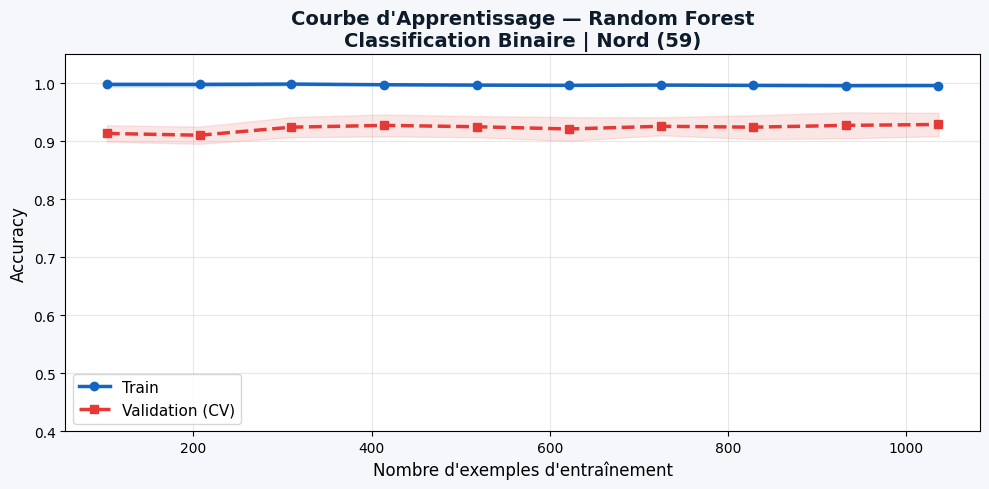

✅ Figure 3 sauvegardée


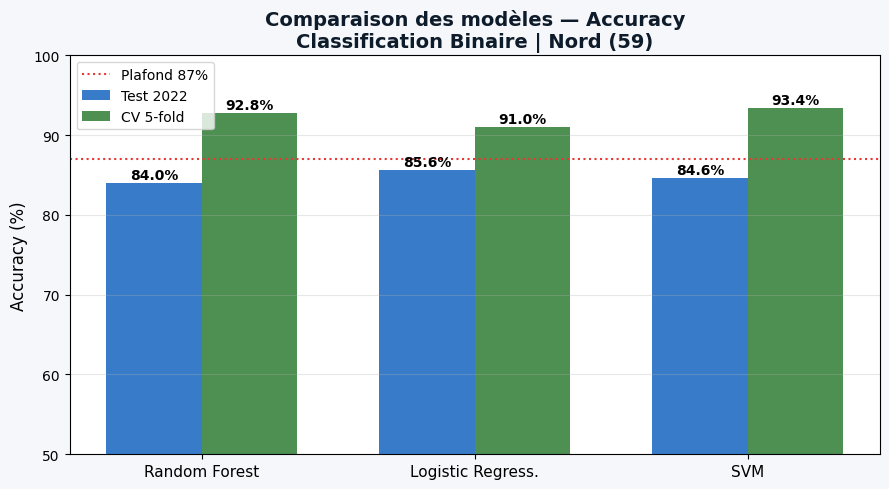

✅ Figure 4 sauvegardée


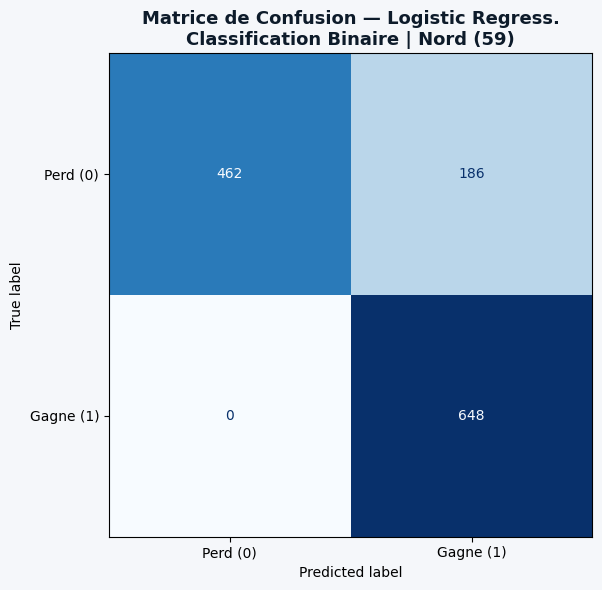

✅ Figure 5 sauvegardée


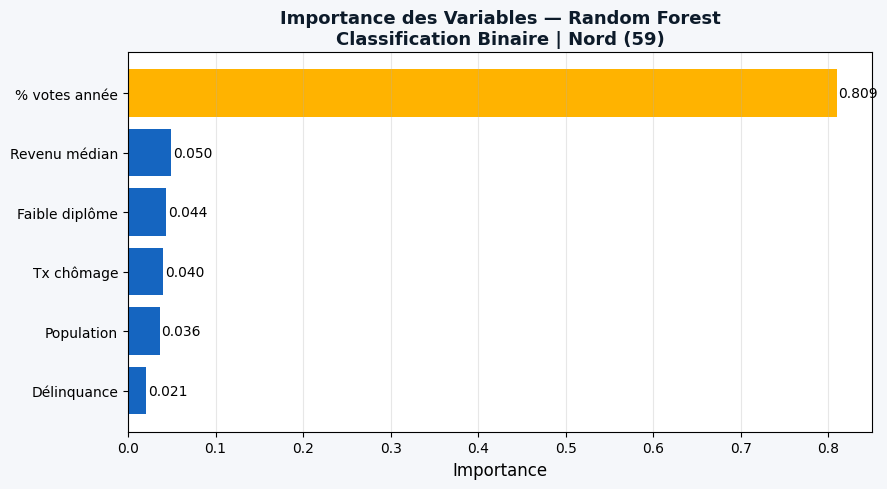

✅ Figure 6 sauvegardée


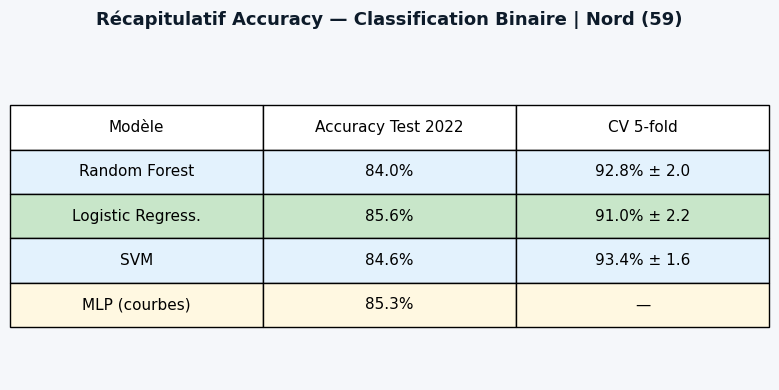

✅ Figure 7 sauvegardée

Candidats bien prédits : 1110 / 1296
✅ Tous les fichiers sauvegardés dans outputs/


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import os

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import learning_curve, cross_val_score

os.makedirs("outputs", exist_ok=True)

# ================================================================
# CHARGEMENT
# ================================================================
df17 = pd.read_csv('/Users/Princia/MSPR/data/final/dataset_ml_2017.csv')
df22 = pd.read_csv('/Users/Princia/MSPR/data/final/dataset_ml_2022.csv')

def extract_top2(df, annee):
    rows = []
    for _, row in df.iterrows():
        for rang, i in enumerate([1, 2], start=1):
            rows.append({
                'commune':               row['libelle_commune'],
                'candidat':              row[f'nom_cand{i}'],
                f'pct_{annee}':          row[f'pct_cand{i}'],
                f'target_{annee}':       1 if rang == 1 else 0,
                'taux_chomage':          row['taux_chomage'],
                'revenu_median':         row['revenu_median'],
                'taux_faible_diplome':   row['taux_faible_diplome'],
                'taux_delinquance':      row['taux_delinquance'],
                'population_municipale': row['population_municipale'],
            })
    return pd.DataFrame(rows)

top2_17 = extract_top2(df17, 2017)
top2_22 = extract_top2(df22, 2022)

print(f"Train (2017) : {len(top2_17)} lignes | target=1 : {top2_17['target_2017'].sum()}, target=0 : {(top2_17['target_2017']==0).sum()}")
print(f"Test  (2022) : {len(top2_22)} lignes | target=1 : {top2_22['target_2022'].sum()}, target=0 : {(top2_22['target_2022']==0).sum()}")

FEATURES      = ['taux_chomage','revenu_median','taux_faible_diplome',
                 'taux_delinquance','population_municipale','pct_2017']
FEATURES_TEST = ['taux_chomage','revenu_median','taux_faible_diplome',
                 'taux_delinquance','population_municipale','pct_2022']

X_train = top2_17[FEATURES].values
y_train = top2_17['target_2017'].values
X_test  = top2_22[FEATURES_TEST].values
y_test  = top2_22['target_2022'].values

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ================================================================
# MODÈLES
# ================================================================
models = {
    "Random Forest":     RandomForestClassifier(n_estimators=100, random_state=42),
    "Logistic Regress.": LogisticRegression(max_iter=1000, random_state=42),
    "SVM":               SVC(kernel="rbf", random_state=42),
}
results = {}
print("\n" + "="*55)
print("RÉSULTATS — Classification Binaire")
print("="*55)
for name, model in models.items():
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    acc    = accuracy_score(y_test, y_pred)
    cv     = cross_val_score(model, X_train_sc, y_train, cv=5)
    results[name] = {'model': model, 'y_pred': y_pred, 'acc': acc, 'cv': cv}
    print(f"\n{name}: Accuracy={acc*100:.1f}% | CV={cv.mean()*100:.1f}%±{cv.std()*100:.1f}%")
    print(classification_report(y_test, y_pred, target_names=["Perd(0)","Gagne(1)"], zero_division=0))

best = max(results, key=lambda k: results[k]['acc'])
print(f"\n✅ Meilleur modèle : {best} ({results[best]['acc']*100:.1f}%)")

# ================================================================
# COURBES MLP
# ================================================================
train_acc_h, val_acc_h, loss_h = [], [], []
mlp = MLPClassifier(hidden_layer_sizes=(64,32), max_iter=1,
                    warm_start=True, random_state=42, learning_rate_init=0.001)
for _ in range(80):
    mlp.fit(X_train_sc, y_train)
    train_acc_h.append(mlp.score(X_train_sc, y_train))
    val_acc_h.append(mlp.score(X_test_sc, y_test))
    loss_h.append(mlp.loss_)
print(f"MLP accuracy : {val_acc_h[-1]*100:.1f}%")

# ================================================================
# COULEURS
# ================================================================
NAVY  = "#0D1B2A"
BLUE  = "#1565C0"
RED   = "#E53935"
GREEN = "#2E7D32"
GOLD  = "#FFB300"

# ================================================================
# FIGURE 1 — Courbe de Précision (MLP)
# ================================================================
fig1, ax1 = plt.subplots(figsize=(10, 5))
fig1.patch.set_facecolor("#F5F7FA")
ax1.plot(train_acc_h, label="Train (2017)", color=BLUE, linewidth=2.5)
ax1.plot(val_acc_h,   label="Validation (2022)", color=RED, linewidth=2.5, linestyle="--")
ax1.axhline(max(val_acc_h), color=GREEN, linestyle=":", linewidth=1.5,
            label=f"Max val = {max(val_acc_h)*100:.1f}%")
ax1.fill_between(range(80), train_acc_h, val_acc_h, alpha=0.07, color=RED)
ax1.set_title("Courbe de Précision — MLP\nClassification Binaire | Nord (59)",
              fontsize=14, fontweight="bold", color=NAVY)
ax1.set_xlabel("Époque", fontsize=12)
ax1.set_ylabel("Accuracy", fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0.4, 1.05)
plt.tight_layout()
plt.savefig("outputs/fig1_courbe_precision.png", dpi=160, bbox_inches="tight", facecolor="#F5F7FA")
plt.show()
print("✅ Figure 1 sauvegardée")

# ================================================================
# FIGURE 2 — Courbe de Perte (MLP)
# ================================================================
fig2, ax2 = plt.subplots(figsize=(10, 5))
fig2.patch.set_facecolor("#F5F7FA")
ax2.plot(loss_h, color="#FF6F00", linewidth=2.5, label="Train Loss")
ax2.fill_between(range(80), loss_h, alpha=0.15, color="#FF6F00")
ax2.set_title("Courbe de Perte (Loss) — MLP\nClassification Binaire | Nord (59)",
              fontsize=14, fontweight="bold", color=NAVY)
ax2.set_xlabel("Époque", fontsize=12)
ax2.set_ylabel("Loss", fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/fig2_courbe_perte.png", dpi=160, bbox_inches="tight", facecolor="#F5F7FA")
plt.show()
print("✅ Figure 2 sauvegardée")

# ================================================================
# FIGURE 3 — Courbe d'Apprentissage (Random Forest)
# ================================================================
ts, tr_sc2, val_sc2 = learning_curve(
    RandomForestClassifier(n_estimators=100, random_state=42),
    X_train_sc, y_train, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring="accuracy", n_jobs=-1)

fig3, ax3 = plt.subplots(figsize=(10, 5))
fig3.patch.set_facecolor("#F5F7FA")
ax3.plot(ts, tr_sc2.mean(1),  label="Train",           color=BLUE, linewidth=2.5, marker="o")
ax3.plot(ts, val_sc2.mean(1), label="Validation (CV)",  color=RED,  linewidth=2.5, linestyle="--", marker="s")
ax3.fill_between(ts, tr_sc2.mean(1)-tr_sc2.std(1),  tr_sc2.mean(1)+tr_sc2.std(1),  alpha=0.12, color=BLUE)
ax3.fill_between(ts, val_sc2.mean(1)-val_sc2.std(1), val_sc2.mean(1)+val_sc2.std(1), alpha=0.12, color=RED)
ax3.set_title("Courbe d'Apprentissage — Random Forest\nClassification Binaire | Nord (59)",
              fontsize=14, fontweight="bold", color=NAVY)
ax3.set_xlabel("Nombre d'exemples d'entraînement", fontsize=12)
ax3.set_ylabel("Accuracy", fontsize=12)
ax3.legend(fontsize=11)
ax3.grid(True, alpha=0.3)
ax3.set_ylim(0.4, 1.05)
plt.tight_layout()
plt.savefig("outputs/fig3_courbe_apprentissage_rf.png", dpi=160, bbox_inches="tight", facecolor="#F5F7FA")
plt.show()
print("✅ Figure 3 sauvegardée")

# ================================================================
# FIGURE 4 — Comparaison des modèles
# ================================================================
fig4, ax4 = plt.subplots(figsize=(9, 5))
fig4.patch.set_facecolor("#F5F7FA")
noms = list(results.keys())
accs = [results[n]['acc']*100 for n in noms]
cvs  = [results[n]['cv'].mean()*100 for n in noms]
x = np.arange(len(noms)); w = 0.35
b1 = ax4.bar(x - w/2, accs, w, label="Test 2022",  color=BLUE,  alpha=0.85)
b2 = ax4.bar(x + w/2, cvs,  w, label="CV 5-fold",  color=GREEN, alpha=0.85)
for b in list(b1) + list(b2):
    ax4.text(b.get_x()+b.get_width()/2, b.get_height()+0.5,
             f"{b.get_height():.1f}%", ha="center", fontsize=10, fontweight="bold")
ax4.axhline(87, color=RED, linestyle=":", linewidth=1.5, label="Plafond 87%")
ax4.set_title("Comparaison des modèles — Accuracy\nClassification Binaire | Nord (59)",
              fontsize=14, fontweight="bold", color=NAVY)
ax4.set_xticks(x)
ax4.set_xticklabels(noms, fontsize=11)
ax4.set_ylabel("Accuracy (%)", fontsize=12)
ax4.legend(fontsize=10)
ax4.set_ylim(50, 100)
ax4.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("outputs/fig4_comparaison_modeles.png", dpi=160, bbox_inches="tight", facecolor="#F5F7FA")
plt.show()
print("✅ Figure 4 sauvegardée")

# ================================================================
# FIGURE 5 — Matrice de Confusion
# ================================================================
fig5, ax5 = plt.subplots(figsize=(7, 6))
fig5.patch.set_facecolor("#F5F7FA")
cm   = confusion_matrix(y_test, results[best]['y_pred'])
disp = ConfusionMatrixDisplay(cm, display_labels=["Perd (0)", "Gagne (1)"])
disp.plot(ax=ax5, colorbar=False, cmap="Blues")
ax5.set_title(f"Matrice de Confusion — {best}\nClassification Binaire | Nord (59)",
              fontsize=13, fontweight="bold", color=NAVY)
plt.tight_layout()
plt.savefig("outputs/fig5_matrice_confusion.png", dpi=160, bbox_inches="tight", facecolor="#F5F7FA")
plt.show()
print("✅ Figure 5 sauvegardée")

# ================================================================
# FIGURE 6 — Importance des variables
# ================================================================
fig6, ax6 = plt.subplots(figsize=(9, 5))
fig6.patch.set_facecolor("#F5F7FA")
feat_labels = ['Tx chômage','Revenu médian','Faible diplôme',
               'Délinquance','Population','% votes année']
imp = results["Random Forest"]['model'].feature_importances_
idx = np.argsort(imp)
bar_colors = [GOLD if i == idx[-1] else BLUE for i in range(len(feat_labels))]
ax6.barh([feat_labels[i] for i in idx], imp[idx], color=[bar_colors[i] for i in idx])
for i, v in enumerate(imp[idx]):
    ax6.text(v + 0.002, i, f"{v:.3f}", va="center", fontsize=10)
ax6.set_title("Importance des Variables — Random Forest\nClassification Binaire | Nord (59)",
              fontsize=13, fontweight="bold", color=NAVY)
ax6.set_xlabel("Importance", fontsize=12)
ax6.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig("outputs/fig6_importance_variables.png", dpi=160, bbox_inches="tight", facecolor="#F5F7FA")
plt.show()
print("✅ Figure 6 sauvegardée")

# ================================================================
# FIGURE 7 — Tableau récapitulatif Accuracy
# ================================================================
fig7, ax7 = plt.subplots(figsize=(8, 4))
fig7.patch.set_facecolor("#F5F7FA")
ax7.axis("off")
td = [["Modèle", "Accuracy Test 2022", "CV 5-fold"]]
tc = [["#1565C0", "#1565C0", "#1565C0"]]
for n in noms:
    td.append([n,
               f"{results[n]['acc']*100:.1f}%",
               f"{results[n]['cv'].mean()*100:.1f}% ± {results[n]['cv'].std()*100:.1f}"])
    tc.append(["#C8E6C9" if n == best else "#E3F2FD"] * 3)
td.append(["MLP (courbes)", f"{val_acc_h[-1]*100:.1f}%", "—"])
tc.append(["#FFF8E1"] * 3)
tbl = ax7.table(cellText=td[1:], colLabels=td[0],
                cellColours=tc[1:], loc="center", cellLoc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.3, 2.5)
ax7.set_title("Récapitulatif Accuracy — Classification Binaire | Nord (59)",
              fontsize=13, fontweight="bold", color=NAVY, pad=20)
plt.tight_layout()
plt.savefig("outputs/fig7_tableau_accuracy.png", dpi=160, bbox_inches="tight", facecolor="#F5F7FA")
plt.show()
print("✅ Figure 7 sauvegardée")

# ================================================================
# CSV
# ================================================================
comp = top2_22[['commune','candidat','pct_2022','target_2022']].copy()
comp['prediction'] = results[best]['y_pred']
comp['correct']    = (comp['prediction'] == comp['target_2022']).astype(int)
comp.to_csv('outputs/comparaison_communes_2022.csv', index=False)
print(f"\nCandidats bien prédits : {comp['correct'].sum()} / {len(comp)}")

top2_17_out  = top2_17[['commune','candidat','pct_2017','target_2017',
                         'taux_chomage','revenu_median','taux_faible_diplome',
                         'taux_delinquance','population_municipale']].copy()
top2_22_out  = top2_22[['commune','candidat','pct_2022','target_2022']].copy()
dataset_prof = pd.merge(top2_17_out, top2_22_out, on=['commune','candidat'], how='outer').fillna(0)
dataset_prof['Tg'] = dataset_prof['target_2022'].astype(int)
dataset_prof.to_csv('outputs/dataset_classification_binaire.csv', index=False)
print("✅ Tous les fichiers sauvegardés dans outputs/")

La classification multiclasse avec Cible partie politique : Gauche - Centre - Droite

Classes : {0: 'CENTRE', 1: 'DROITE', 2: 'GAUCHE'}

Train (2017) : 648 communes
  CENTRE : 36 (5.6%)
  DROITE : 598 (92.3%)
  GAUCHE : 14 (2.2%)

Test  (2022) : 648 communes
  CENTRE : 165 (25.5%)
  DROITE : 470 (72.5%)
  GAUCHE : 13 (2.0%)

RÉSULTATS — Classification Multi-Classe

Random Forest: Accuracy=72.7% | CV=92.9%±0.6%
              precision    recall  f1-score   support

      CENTRE       0.00      0.00      0.00       165
      DROITE       0.73      1.00      0.84       470
      GAUCHE       1.00      0.08      0.14        13

    accuracy                           0.73       648
   macro avg       0.58      0.36      0.33       648
weighted avg       0.55      0.73      0.61       648


Gradient Boosting: Accuracy=75.0% | CV=90.6%±2.0%
              precision    recall  f1-score   support

      CENTRE       0.81      0.10      0.18       165
      DROITE       0.75      0.99      0.85       470
      GAUCHE       0.60      0.23      0.33        13

    accuracy          

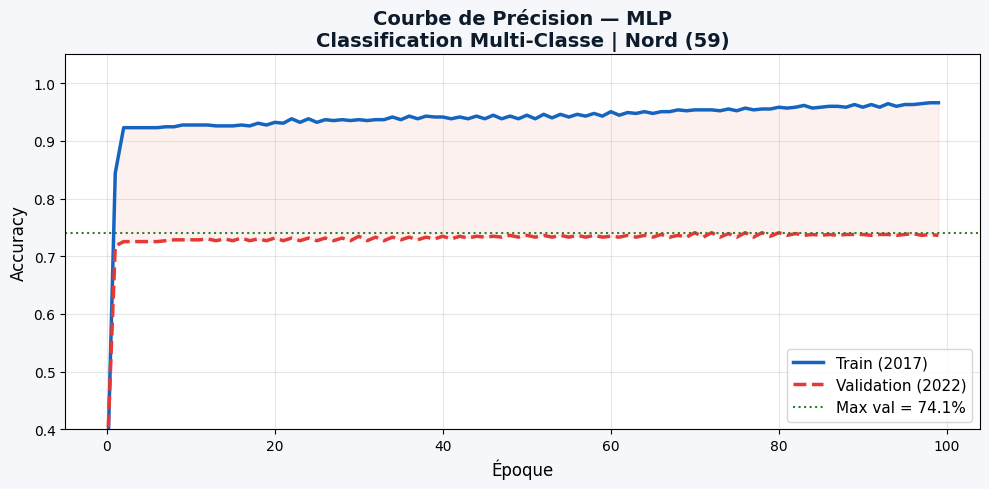

✅ Figure 1 sauvegardée


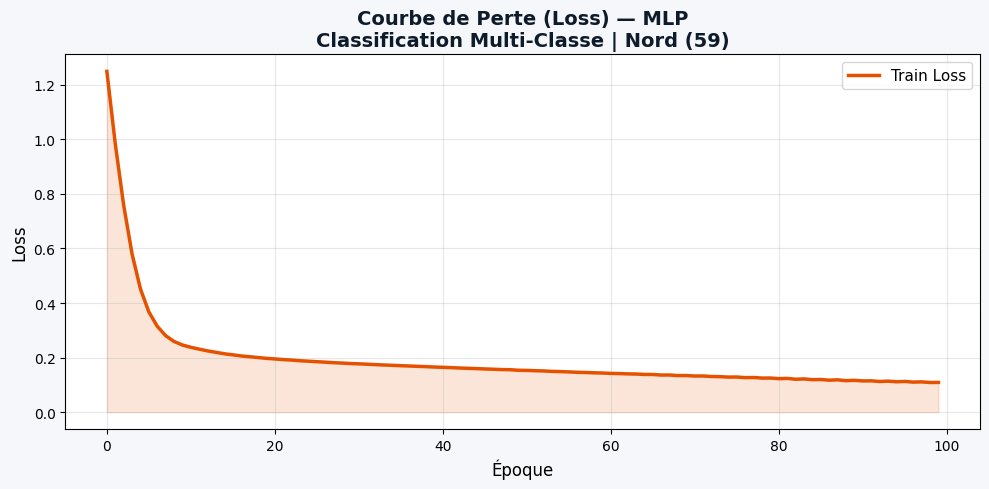

✅ Figure 2 sauvegardée


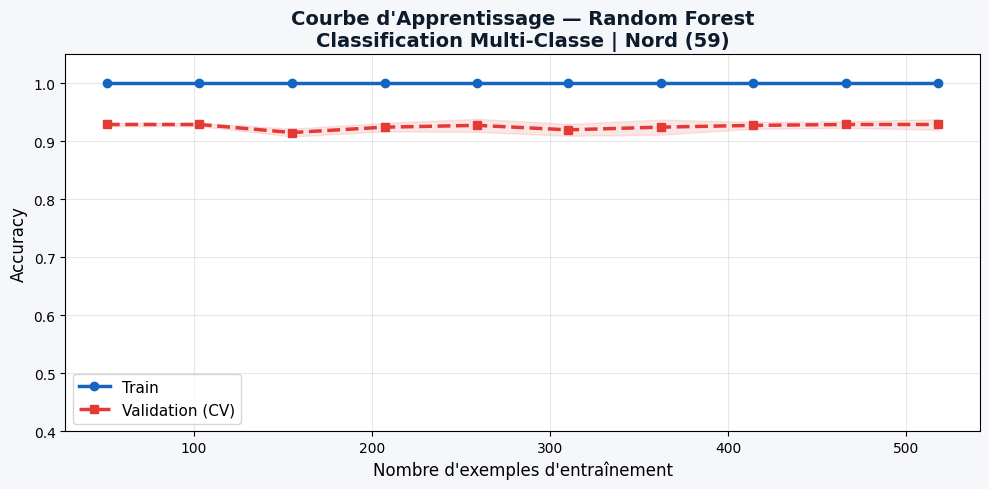

✅ Figure 3 sauvegardée


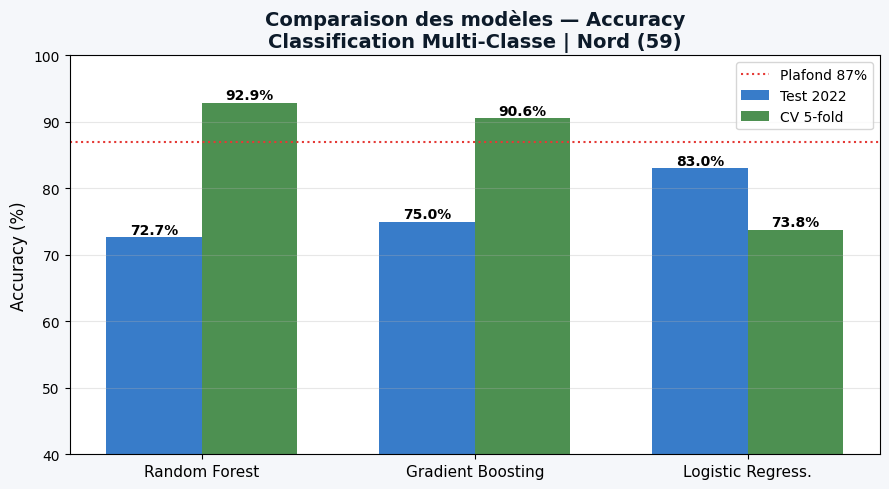

✅ Figure 4 sauvegardée


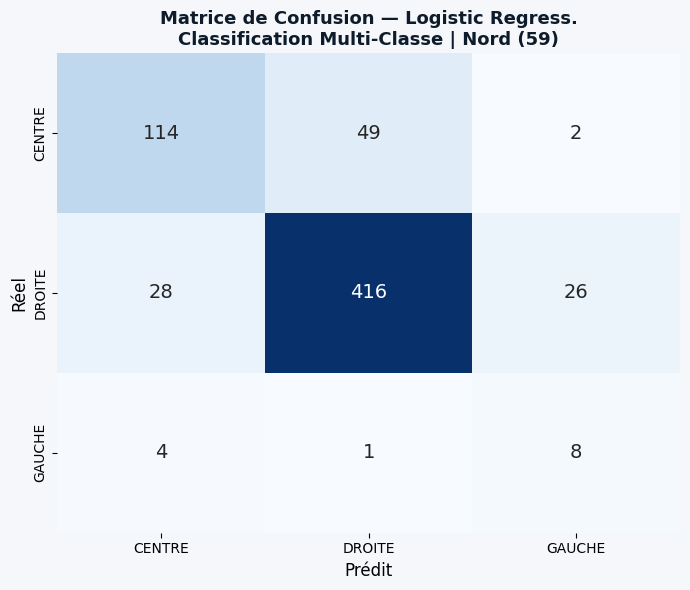

✅ Figure 5 sauvegardée


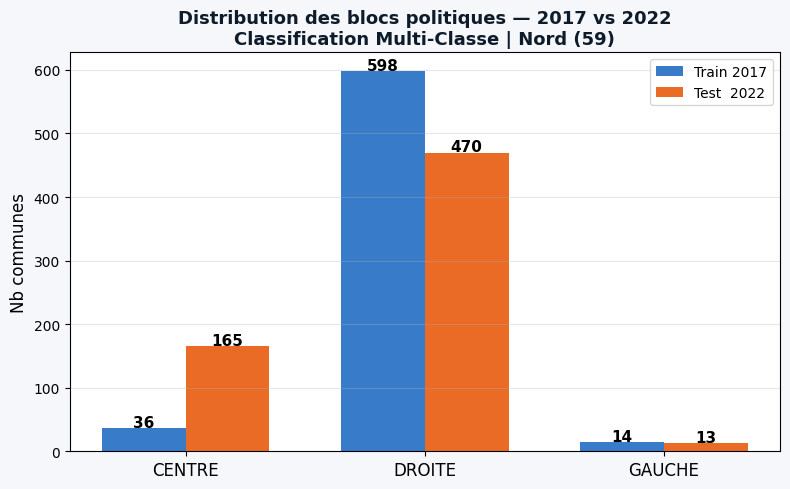

✅ Figure 6 sauvegardée


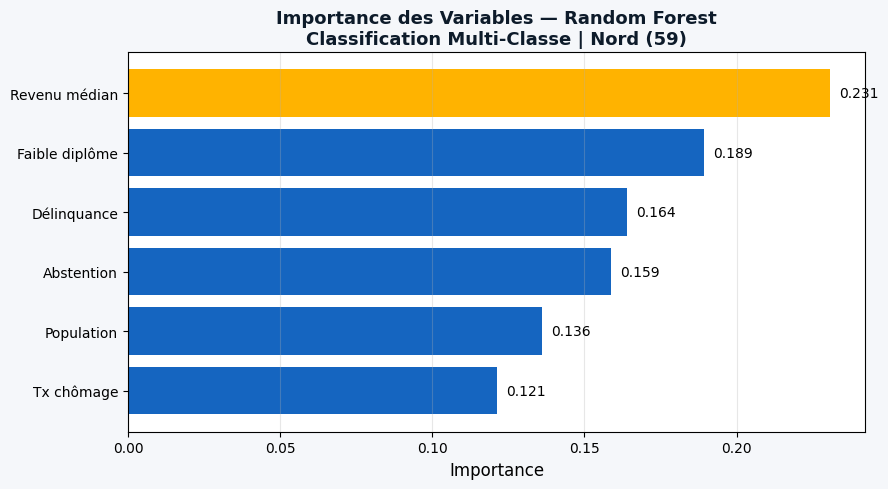

✅ Figure 7 sauvegardée


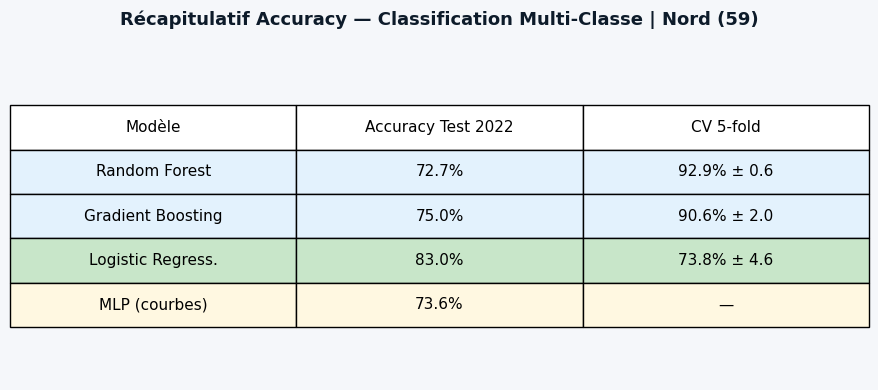

✅ Figure 8 sauvegardée

📊 Récap par bloc politique :
Bloc        Correct   Total   Accuracy
──────────────────────────────────────
CENTRE          114     165      69.1%
DROITE          416     470      88.5%
GAUCHE            8      13      61.5%

TOTAL           538     648      83.0%

✅ Tous les fichiers sauvegardés dans outputs/


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import os

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import learning_curve, cross_val_score

os.makedirs("outputs", exist_ok=True)

# ================================================================
# CHARGEMENT
# ================================================================
df = pd.read_csv('/Users/Princia/MSPR/data/final/dataset_ml_final.csv')

# ================================================================
# TARGET : bloc politique vainqueur (CENTRE=0, DROITE=1, GAUCHE=2)
# ================================================================
le = LabelEncoder()
df['target_mc'] = le.fit_transform(df['bloc_vainqueur'])
label_names = {i: c for i, c in enumerate(le.classes_)}
print("Classes :", label_names)

FEATURES = ['taux_chomage', 'revenu_median', 'taux_faible_diplome',
            'taux_delinquance', 'population_municipale', 'pct_abstention']

train = df[df['annee'] == 2017]
test  = df[df['annee'] == 2022]

print(f"\nTrain (2017) : {len(train)} communes")
for c, n in train['target_mc'].value_counts().sort_index().items():
    print(f"  {label_names[c]} : {n} ({n/len(train)*100:.1f}%)")

print(f"\nTest  (2022) : {len(test)} communes")
for c, n in test['target_mc'].value_counts().sort_index().items():
    print(f"  {label_names[c]} : {n} ({n/len(test)*100:.1f}%)")

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(train[FEATURES].values)
X_test_sc  = scaler.transform(test[FEATURES].values)
y_train    = train['target_mc'].values
y_test     = test['target_mc'].values

# ================================================================
# MODÈLES
# ================================================================
models = {
    "Random Forest":     RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced'),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "Logistic Regress.": LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
}
results = {}
print("\n" + "="*60)
print("RÉSULTATS — Classification Multi-Classe")
print("="*60)
for name, model in models.items():
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    acc    = accuracy_score(y_test, y_pred)
    cv     = cross_val_score(model, X_train_sc, y_train, cv=5)
    results[name] = {'model': model, 'y_pred': y_pred, 'acc': acc, 'cv': cv}
    print(f"\n{name}: Accuracy={acc*100:.1f}% | CV={cv.mean()*100:.1f}%±{cv.std()*100:.1f}%")
    print(classification_report(y_test, y_pred,
          target_names=list(label_names.values()), zero_division=0))

best = max(results, key=lambda k: results[k]['acc'])
print(f"\n✅ Meilleur modèle : {best} ({results[best]['acc']*100:.1f}%)")

# ================================================================
# COURBES MLP
# ================================================================
train_acc_h, val_acc_h, loss_h = [], [], []
mlp = MLPClassifier(hidden_layer_sizes=(128, 64, 32), max_iter=1,
                    warm_start=True, random_state=42, learning_rate_init=0.001)
for _ in range(100):
    mlp.fit(X_train_sc, y_train)
    train_acc_h.append(mlp.score(X_train_sc, y_train))
    val_acc_h.append(mlp.score(X_test_sc, y_test))
    loss_h.append(mlp.loss_)
print(f"MLP accuracy : {val_acc_h[-1]*100:.1f}%")

# ================================================================
# COULEURS
# ================================================================
NAVY   = "#0D1B2A"
BLUE   = "#1565C0"
RED    = "#E53935"
GREEN  = "#2E7D32"
GOLD   = "#FFB300"
ORANGE = "#E65100"

# ================================================================
# FIGURE 1 — Courbe de Précision (MLP)
# ================================================================
fig1, ax1 = plt.subplots(figsize=(10, 5))
fig1.patch.set_facecolor("#F5F7FA")
ax1.plot(train_acc_h, label="Train (2017)",      color=BLUE, linewidth=2.5)
ax1.plot(val_acc_h,   label="Validation (2022)", color=RED,  linewidth=2.5, linestyle="--")
ax1.axhline(max(val_acc_h), color=GREEN, linestyle=":", linewidth=1.5,
            label=f"Max val = {max(val_acc_h)*100:.1f}%")
ax1.fill_between(range(100), train_acc_h, val_acc_h, alpha=0.07, color=RED)
ax1.set_title("Courbe de Précision — MLP\nClassification Multi-Classe | Nord (59)",
              fontsize=14, fontweight="bold", color=NAVY)
ax1.set_xlabel("Époque", fontsize=12)
ax1.set_ylabel("Accuracy", fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0.4, 1.05)
plt.tight_layout()
plt.savefig("outputs/mc_fig1_courbe_precision.png", dpi=160, bbox_inches="tight", facecolor="#F5F7FA")
plt.show()
print("✅ Figure 1 sauvegardée")

# ================================================================
# FIGURE 2 — Courbe de Perte (MLP)
# ================================================================
fig2, ax2 = plt.subplots(figsize=(10, 5))
fig2.patch.set_facecolor("#F5F7FA")
ax2.plot(loss_h, color=ORANGE, linewidth=2.5, label="Train Loss")
ax2.fill_between(range(100), loss_h, alpha=0.15, color=ORANGE)
ax2.set_title("Courbe de Perte (Loss) — MLP\nClassification Multi-Classe | Nord (59)",
              fontsize=14, fontweight="bold", color=NAVY)
ax2.set_xlabel("Époque", fontsize=12)
ax2.set_ylabel("Loss", fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/mc_fig2_courbe_perte.png", dpi=160, bbox_inches="tight", facecolor="#F5F7FA")
plt.show()
print("✅ Figure 2 sauvegardée")

# ================================================================
# FIGURE 3 — Courbe d'Apprentissage (Random Forest)
# ================================================================
ts, tr2, val2 = learning_curve(
    RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    X_train_sc, y_train, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring="accuracy", n_jobs=-1)

fig3, ax3 = plt.subplots(figsize=(10, 5))
fig3.patch.set_facecolor("#F5F7FA")
ax3.plot(ts, tr2.mean(1),  label="Train",           color=BLUE, linewidth=2.5, marker="o")
ax3.plot(ts, val2.mean(1), label="Validation (CV)",  color=RED,  linewidth=2.5, linestyle="--", marker="s")
ax3.fill_between(ts, tr2.mean(1)-tr2.std(1),  tr2.mean(1)+tr2.std(1),  alpha=0.12, color=BLUE)
ax3.fill_between(ts, val2.mean(1)-val2.std(1), val2.mean(1)+val2.std(1), alpha=0.12, color=RED)
ax3.set_title("Courbe d'Apprentissage — Random Forest\nClassification Multi-Classe | Nord (59)",
              fontsize=14, fontweight="bold", color=NAVY)
ax3.set_xlabel("Nombre d'exemples d'entraînement", fontsize=12)
ax3.set_ylabel("Accuracy", fontsize=12)
ax3.legend(fontsize=11)
ax3.grid(True, alpha=0.3)
ax3.set_ylim(0.4, 1.05)
plt.tight_layout()
plt.savefig("outputs/mc_fig3_courbe_apprentissage_rf.png", dpi=160, bbox_inches="tight", facecolor="#F5F7FA")
plt.show()
print("✅ Figure 3 sauvegardée")

# ================================================================
# FIGURE 4 — Comparaison des modèles
# ================================================================
fig4, ax4 = plt.subplots(figsize=(9, 5))
fig4.patch.set_facecolor("#F5F7FA")
noms = list(results.keys())
accs = [results[n]['acc']*100 for n in noms]
cvs  = [results[n]['cv'].mean()*100 for n in noms]
x = np.arange(len(noms)); w = 0.35
b1 = ax4.bar(x - w/2, accs, w, label="Test 2022",  color=BLUE,  alpha=0.85)
b2 = ax4.bar(x + w/2, cvs,  w, label="CV 5-fold",  color=GREEN, alpha=0.85)
for b in list(b1) + list(b2):
    ax4.text(b.get_x()+b.get_width()/2, b.get_height()+0.5,
             f"{b.get_height():.1f}%", ha="center", fontsize=10, fontweight="bold")
ax4.axhline(87, color=RED, linestyle=":", linewidth=1.5, label="Plafond 87%")
ax4.set_title("Comparaison des modèles — Accuracy\nClassification Multi-Classe | Nord (59)",
              fontsize=14, fontweight="bold", color=NAVY)
ax4.set_xticks(x)
ax4.set_xticklabels(noms, fontsize=11)
ax4.set_ylabel("Accuracy (%)", fontsize=12)
ax4.legend(fontsize=10)
ax4.set_ylim(40, 100)
ax4.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("outputs/mc_fig4_comparaison_modeles.png", dpi=160, bbox_inches="tight", facecolor="#F5F7FA")
plt.show()
print("✅ Figure 4 sauvegardée")

# ================================================================
# FIGURE 5 — Matrice de Confusion
# ================================================================
fig5, ax5 = plt.subplots(figsize=(7, 6))
fig5.patch.set_facecolor("#F5F7FA")
class_lbls = list(label_names.values())
cm = confusion_matrix(y_test, results[best]['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_lbls, yticklabels=class_lbls,
            ax=ax5, cbar=False, annot_kws={"size": 14})
ax5.set_title(f"Matrice de Confusion — {best}\nClassification Multi-Classe | Nord (59)",
              fontsize=13, fontweight="bold", color=NAVY)
ax5.set_ylabel("Réel", fontsize=12)
ax5.set_xlabel("Prédit", fontsize=12)
plt.tight_layout()
plt.savefig("outputs/mc_fig5_matrice_confusion.png", dpi=160, bbox_inches="tight", facecolor="#F5F7FA")
plt.show()
print("✅ Figure 5 sauvegardée")

# ================================================================
# FIGURE 6 — Distribution des blocs 2017 vs 2022
# ================================================================
fig6, ax6 = plt.subplots(figsize=(8, 5))
fig6.patch.set_facecolor("#F5F7FA")
classes_all = sorted(label_names.keys())
c17 = [np.sum(y_train == c) for c in classes_all]
c22 = [np.sum(y_test  == c) for c in classes_all]
x2 = np.arange(len(classes_all)); w2 = 0.35
bx1 = ax6.bar(x2 - w2/2, c17, w2, label="Train 2017", color=BLUE,   alpha=0.85)
bx2 = ax6.bar(x2 + w2/2, c22, w2, label="Test  2022", color=ORANGE, alpha=0.85)
for b in list(bx1) + list(bx2):
    ax6.text(b.get_x()+b.get_width()/2, b.get_height()+2,
             str(int(b.get_height())), ha="center", fontsize=11, fontweight="bold")
ax6.set_title("Distribution des blocs politiques — 2017 vs 2022\nClassification Multi-Classe | Nord (59)",
              fontsize=13, fontweight="bold", color=NAVY)
ax6.set_xticks(x2)
ax6.set_xticklabels(class_lbls, fontsize=12)
ax6.set_ylabel("Nb communes", fontsize=12)
ax6.legend(fontsize=10)
ax6.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("outputs/mc_fig6_distribution_blocs.png", dpi=160, bbox_inches="tight", facecolor="#F5F7FA")
plt.show()
print("✅ Figure 6 sauvegardée")

# ================================================================
# FIGURE 7 — Importance des variables
# ================================================================
fig7, ax7 = plt.subplots(figsize=(9, 5))
fig7.patch.set_facecolor("#F5F7FA")
feat_labels = ['Tx chômage', 'Revenu médian', 'Faible diplôme',
               'Délinquance', 'Population', 'Abstention']
imp = results["Random Forest"]['model'].feature_importances_
idx = np.argsort(imp)
bar_colors = [GOLD if i == idx[-1] else BLUE for i in range(len(feat_labels))]
ax7.barh([feat_labels[i] for i in idx], imp[idx],
         color=[bar_colors[i] for i in idx])
for i, v in enumerate(imp[idx]):
    ax7.text(v + 0.003, i, f"{v:.3f}", va="center", fontsize=10)
ax7.set_title("Importance des Variables — Random Forest\nClassification Multi-Classe | Nord (59)",
              fontsize=13, fontweight="bold", color=NAVY)
ax7.set_xlabel("Importance", fontsize=12)
ax7.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig("outputs/mc_fig7_importance_variables.png", dpi=160, bbox_inches="tight", facecolor="#F5F7FA")
plt.show()
print("✅ Figure 7 sauvegardée")

# ================================================================
# FIGURE 8 — Tableau récapitulatif Accuracy
# ================================================================
fig8, ax8 = plt.subplots(figsize=(9, 4))
fig8.patch.set_facecolor("#F5F7FA")
ax8.axis("off")
td = [["Modèle", "Accuracy Test 2022", "CV 5-fold"]]
tc = [["#1565C0"] * 3]
for n in noms:
    td.append([n,
               f"{results[n]['acc']*100:.1f}%",
               f"{results[n]['cv'].mean()*100:.1f}% ± {results[n]['cv'].std()*100:.1f}"])
    tc.append(["#C8E6C9" if n == best else "#E3F2FD"] * 3)
td.append(["MLP (courbes)", f"{val_acc_h[-1]*100:.1f}%", "—"])
tc.append(["#FFF8E1"] * 3)
tbl = ax8.table(cellText=td[1:], colLabels=td[0],
                cellColours=tc[1:], loc="center", cellLoc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.3, 2.5)
ax8.set_title("Récapitulatif Accuracy — Classification Multi-Classe | Nord (59)",
              fontsize=13, fontweight="bold", color=NAVY, pad=20)
plt.tight_layout()
plt.savefig("outputs/mc_fig8_tableau_accuracy.png", dpi=160, bbox_inches="tight", facecolor="#F5F7FA")
plt.show()
print("✅ Figure 8 sauvegardée")

# ================================================================
# CSV
# ================================================================
comp = test[['libelle_commune', 'bloc_vainqueur', 'target_mc']].copy().reset_index(drop=True)
comp.rename(columns={'libelle_commune': 'commune'}, inplace=True)
comp['target_label']     = comp['target_mc'].map(label_names)
comp['prediction']       = results[best]['y_pred']
comp['prediction_label'] = comp['prediction'].map(label_names)
comp['correct']          = (comp['prediction'] == comp['target_mc']).astype(int)
comp.to_csv("outputs/mc_comparaison_blocs_2022.csv", index=False)

print(f"\n📊 Récap par bloc politique :")
print(f"{'Bloc':<10} {'Correct':>8} {'Total':>7} {'Accuracy':>10}")
print("─" * 38)
for c in sorted(label_names.keys()):
    sub = comp[comp['target_mc'] == c]
    if len(sub) == 0:
        continue
    ok = sub['correct'].sum()
    print(f"{label_names[c]:<10} {ok:>8} {len(sub):>7} {ok/len(sub)*100:>9.1f}%")
print(f"\n{'TOTAL':<10} {comp['correct'].sum():>8} "
      f"{len(comp):>7} {comp['correct'].mean()*100:>9.1f}%")
print("\n✅ Tous les fichiers sauvegardés dans outputs/")

Classes : {0: 'CENTRE', 1: 'DROITE', 2: 'GAUCHE'}

Train (2017) : 648 communes
Répartition 2017 :
  CENTRE : 36 (5.6%)
  DROITE : 598 (92.3%)
  GAUCHE : 14 (2.2%)

Test  (2022) : 648 communes
Répartition 2022 :
  CENTRE : 165 (25.5%)
  DROITE : 470 (72.5%)
  GAUCHE : 13 (2.0%)

RÉSULTATS — Multi-Classe : Bloc politique vainqueur

Random Forest: Accuracy=72.7% | CV=92.9%±0.6%
              precision    recall  f1-score   support

      CENTRE       0.00      0.00      0.00       165
      DROITE       0.73      1.00      0.84       470
      GAUCHE       1.00      0.08      0.14        13

    accuracy                           0.73       648
   macro avg       0.58      0.36      0.33       648
weighted avg       0.55      0.73      0.61       648


Gradient Boosting: Accuracy=75.0% | CV=90.6%±2.0%
              precision    recall  f1-score   support

      CENTRE       0.81      0.10      0.18       165
      DROITE       0.75      0.99      0.85       470
      GAUCHE       0.60    

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/classification_multiclasse_blocs.png'

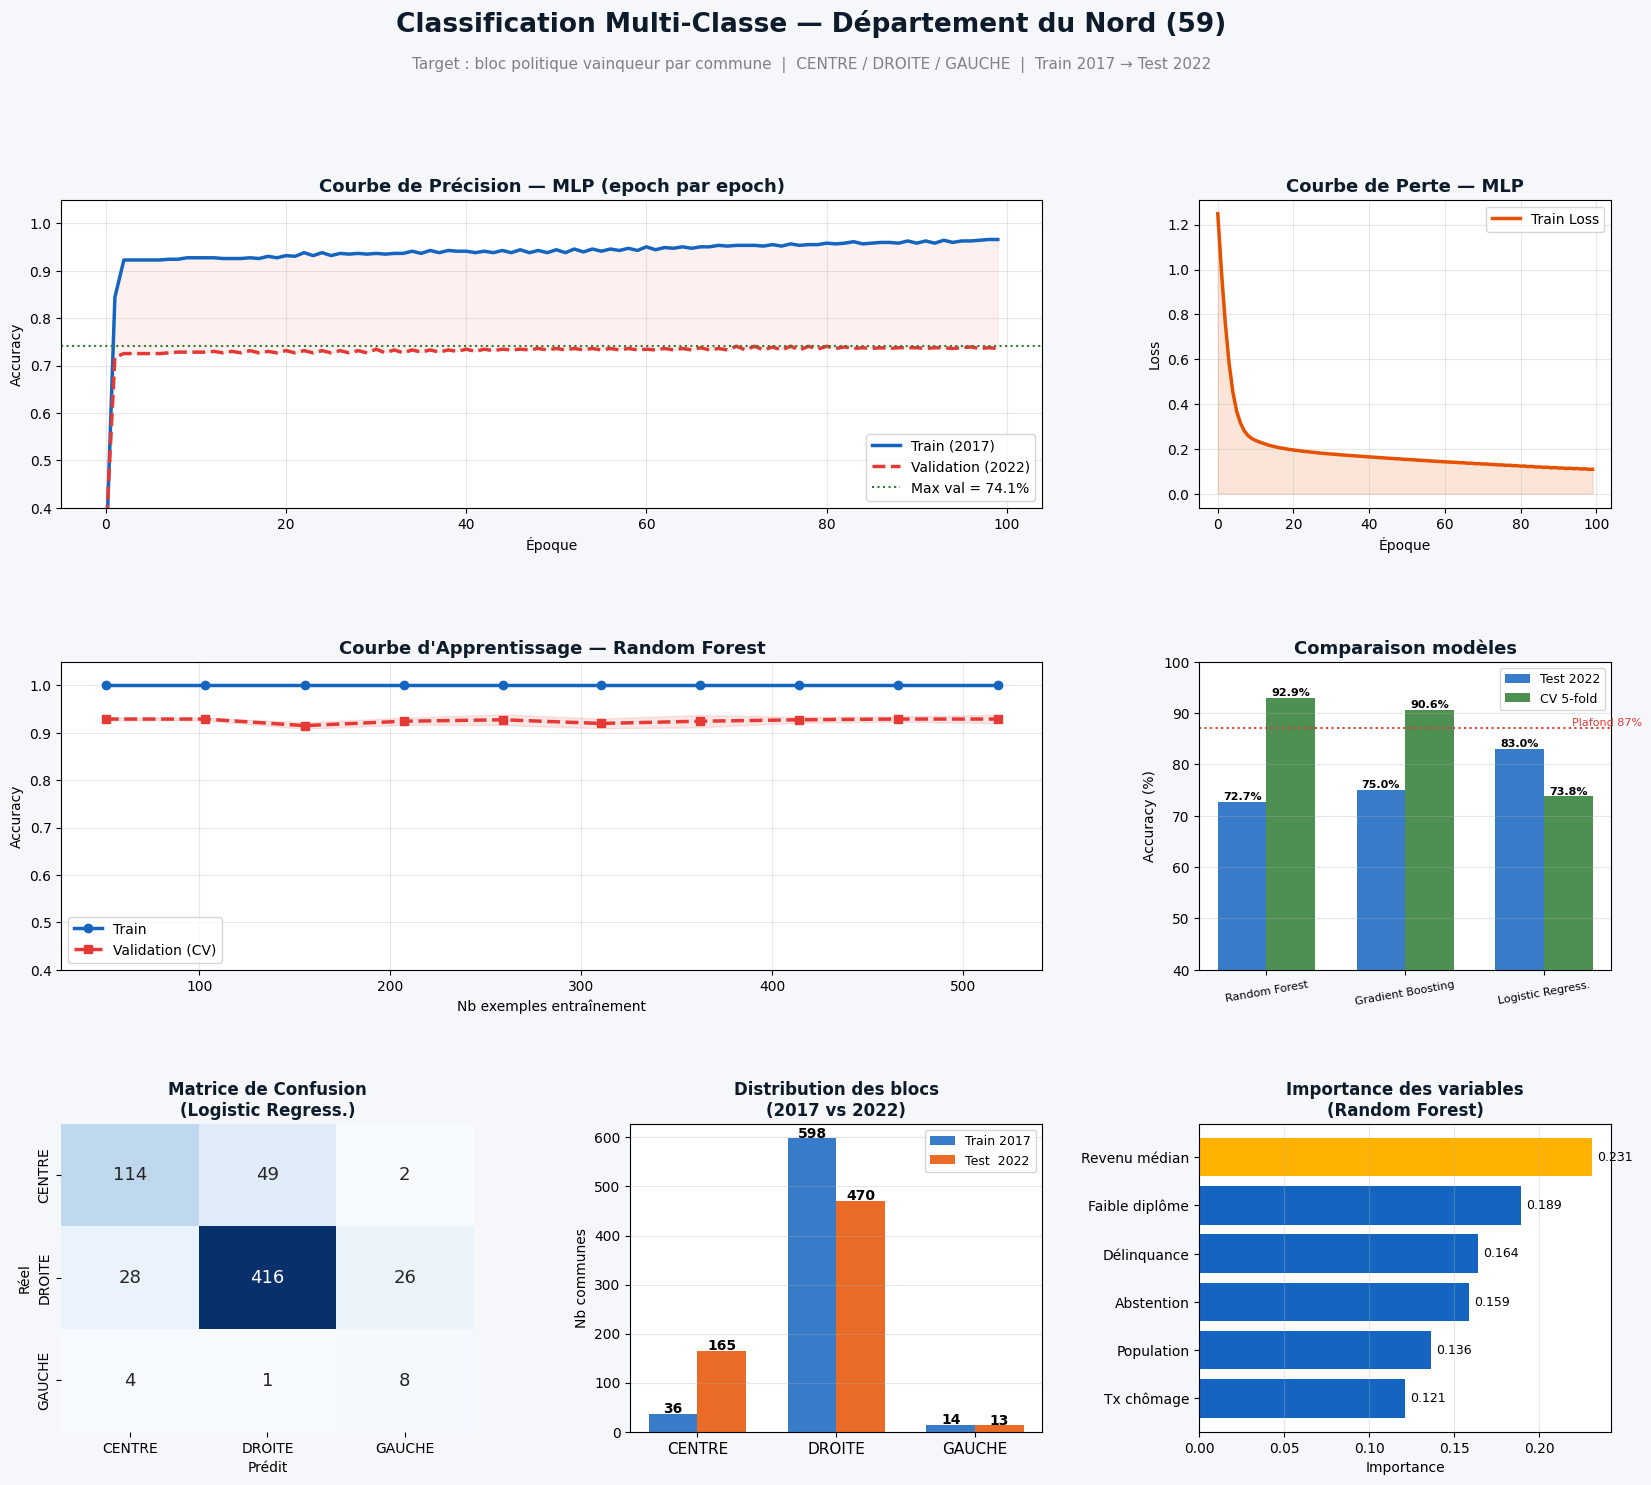

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import learning_curve, cross_val_score

df = pd.read_csv('/Users/Princia/MSPR/data/final/dataset_ml_final.csv')

# ════════════════════════════════════════════════════════════════
# TARGET MULTI-CLASSE : bloc politique vainqueur par commune
# CENTRE=0, DROITE=1, GAUCHE=2  — directement exploitable
# ════════════════════════════════════════════════════════════════
le = LabelEncoder()
df['target_mc'] = le.fit_transform(df['bloc_vainqueur'])
# CENTRE=0, DROITE=1, GAUCHE=2
label_names = {i: c for i, c in enumerate(le.classes_)}
print("Classes :", label_names)
print()

FEATURES = ['taux_chomage','revenu_median','taux_faible_diplome',
            'taux_delinquance','population_municipale','pct_abstention']

train = df[df['annee'] == 2017]
test  = df[df['annee'] == 2022]

print(f"Train (2017) : {len(train)} communes")
print("Répartition 2017 :")
for c, n in train['target_mc'].value_counts().sort_index().items():
    print(f"  {label_names[c]} : {n} ({n/len(train)*100:.1f}%)")

print(f"\nTest  (2022) : {len(test)} communes")
print("Répartition 2022 :")
for c, n in test['target_mc'].value_counts().sort_index().items():
    print(f"  {label_names[c]} : {n} ({n/len(test)*100:.1f}%)")

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(train[FEATURES].values)
X_test_sc  = scaler.transform(test[FEATURES].values)
y_train    = train['target_mc'].values
y_test     = test['target_mc'].values

# ════════════════════════════════════════════════════════════════
# MODÈLES
# ════════════════════════════════════════════════════════════════
models = {
    "Random Forest":     RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced'),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "Logistic Regress.": LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
}
results = {}
print("\n" + "="*60)
print("RÉSULTATS — Multi-Classe : Bloc politique vainqueur")
print("="*60)
for name, model in models.items():
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    acc    = accuracy_score(y_test, y_pred)
    cv     = cross_val_score(model, X_train_sc, y_train, cv=5)
    results[name] = {'model': model, 'y_pred': y_pred, 'acc': acc, 'cv': cv}
    print(f"\n{name}: Accuracy={acc*100:.1f}% | CV={cv.mean()*100:.1f}%±{cv.std()*100:.1f}%")
    print(classification_report(y_test, y_pred,
          target_names=list(label_names.values()), zero_division=0))

best = max(results, key=lambda k: results[k]['acc'])
print(f"\n✅ Meilleur modèle : {best} ({results[best]['acc']*100:.1f}%)")

# ════════════════════════════════════════════════════════════════
# MLP — COURBES
# ════════════════════════════════════════════════════════════════
train_acc_h, val_acc_h, loss_h = [], [], []
mlp = MLPClassifier(hidden_layer_sizes=(128,64,32), max_iter=1,
                    warm_start=True, random_state=42, learning_rate_init=0.001)
for _ in range(100):
    mlp.fit(X_train_sc, y_train)
    train_acc_h.append(mlp.score(X_train_sc, y_train))
    val_acc_h.append(mlp.score(X_test_sc, y_test))
    loss_h.append(mlp.loss_)
print(f"MLP accuracy : {val_acc_h[-1]*100:.1f}%")

# ════════════════════════════════════════════════════════════════
# FIGURE
# ════════════════════════════════════════════════════════════════
NAVY="#0D1B2A"; BLUE="#1565C0"; RED="#E53935"; GREEN="#2E7D32"
GOLD="#FFB300"; ORANGE="#E65100"; PURPLE="#6A1B9A"
CLASS_COLORS = [BLUE, RED, GREEN]

fig = plt.figure(figsize=(20, 16))
fig.patch.set_facecolor("#F5F7FA")
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.38)

fig.text(0.5, 0.985,
         "Classification Multi-Classe — Département du Nord (59)",
         ha="center", fontsize=19, fontweight="bold", color=NAVY)
fig.text(0.5, 0.962,
         "Target : bloc politique vainqueur par commune  |  CENTRE / DROITE / GAUCHE  |  Train 2017 → Test 2022",
         ha="center", fontsize=11, color="gray")

# G1 — Courbe précision MLP
ax1 = fig.add_subplot(gs[0, 0:2])
ax1.plot(train_acc_h, label="Train (2017)", color=BLUE, linewidth=2.5)
ax1.plot(val_acc_h,   label="Validation (2022)", color=RED, linewidth=2.5, linestyle="--")
ax1.axhline(max(val_acc_h), color=GREEN, linestyle=":", linewidth=1.5,
            label=f"Max val = {max(val_acc_h)*100:.1f}%")
ax1.fill_between(range(100), train_acc_h, val_acc_h, alpha=0.07, color=RED)
ax1.set_title("Courbe de Précision — MLP (epoch par epoch)",
              fontsize=13, fontweight="bold", color=NAVY)
ax1.set_xlabel("Époque") ; ax1.set_ylabel("Accuracy")
ax1.legend(fontsize=10) ; ax1.grid(True, alpha=0.3) ; ax1.set_ylim(0.4, 1.05)

# G2 — Courbe perte MLP
ax2 = fig.add_subplot(gs[0, 2])
ax2.plot(loss_h, color=ORANGE, linewidth=2.5, label="Train Loss")
ax2.fill_between(range(100), loss_h, alpha=0.15, color=ORANGE)
ax2.set_title("Courbe de Perte — MLP",
              fontsize=13, fontweight="bold", color=NAVY)
ax2.set_xlabel("Époque") ; ax2.set_ylabel("Loss")
ax2.legend(fontsize=10) ; ax2.grid(True, alpha=0.3)

# G3 — Learning curve RF
ax3 = fig.add_subplot(gs[1, 0:2])
ts, tr2, val2 = learning_curve(
    RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    X_train_sc, y_train, cv=5,
    train_sizes=np.linspace(0.1,1.0,10), scoring="accuracy", n_jobs=-1)
ax3.plot(ts, tr2.mean(1),  label="Train",           color=BLUE, linewidth=2.5, marker="o")
ax3.plot(ts, val2.mean(1), label="Validation (CV)",  color=RED,  linewidth=2.5, linestyle="--", marker="s")
ax3.fill_between(ts, tr2.mean(1)-tr2.std(1),  tr2.mean(1)+tr2.std(1),  alpha=0.12, color=BLUE)
ax3.fill_between(ts, val2.mean(1)-val2.std(1), val2.mean(1)+val2.std(1), alpha=0.12, color=RED)
ax3.set_title("Courbe d'Apprentissage — Random Forest",
              fontsize=13, fontweight="bold", color=NAVY)
ax3.set_xlabel("Nb exemples entraînement") ; ax3.set_ylabel("Accuracy")
ax3.legend(fontsize=10) ; ax3.grid(True, alpha=0.3) ; ax3.set_ylim(0.4, 1.05)

# G4 — Comparaison modèles
ax4 = fig.add_subplot(gs[1, 2])
noms = list(results.keys())
accs = [results[n]['acc']*100 for n in noms]
cvs  = [results[n]['cv'].mean()*100 for n in noms]
x = np.arange(len(noms)) ; w = 0.35
b1 = ax4.bar(x-w/2, accs, w, label="Test 2022",  color=BLUE,  alpha=0.85)
b2 = ax4.bar(x+w/2, cvs,  w, label="CV 5-fold",  color=GREEN, alpha=0.85)
for b in list(b1)+list(b2):
    ax4.text(b.get_x()+b.get_width()/2, b.get_height()+0.4,
             f"{b.get_height():.1f}%", ha="center", fontsize=8, fontweight="bold")
ax4.axhline(87, color=RED, linestyle=":", linewidth=1.5)
ax4.text(2.2, 87.5, "Plafond 87%", fontsize=8, color=RED)
ax4.set_title("Comparaison modèles",
              fontsize=13, fontweight="bold", color=NAVY)
ax4.set_xticks(x) ; ax4.set_xticklabels(noms, fontsize=8, rotation=10)
ax4.set_ylabel("Accuracy (%)") ; ax4.legend(fontsize=9)
ax4.set_ylim(40, 100) ; ax4.grid(True, alpha=0.3, axis="y")

# G5 — Matrice de confusion
ax5 = fig.add_subplot(gs[2, 0])
cm = confusion_matrix(y_test, results[best]['y_pred'])
class_lbls = list(label_names.values())
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_lbls, yticklabels=class_lbls,
            ax=ax5, cbar=False, annot_kws={"size": 13})
ax5.set_title(f"Matrice de Confusion\n({best})",
              fontsize=12, fontweight="bold", color=NAVY)
ax5.set_ylabel("Réel") ; ax5.set_xlabel("Prédit")

# G6 — Distribution 2017 vs 2022
ax6 = fig.add_subplot(gs[2, 1])
classes_all = sorted(label_names.keys())
c17 = [np.sum(y_train==c) for c in classes_all]
c22 = [np.sum(y_test==c)  for c in classes_all]
x2 = np.arange(len(classes_all)) ; w2 = 0.35
bx1 = ax6.bar(x2-w2/2, c17, w2, label="Train 2017", color=BLUE,   alpha=0.85)
bx2 = ax6.bar(x2+w2/2, c22, w2, label="Test  2022", color=ORANGE, alpha=0.85)
for b in list(bx1)+list(bx2):
    ax6.text(b.get_x()+b.get_width()/2, b.get_height()+2,
             str(int(b.get_height())), ha="center", fontsize=10, fontweight="bold")
ax6.set_title("Distribution des blocs\n(2017 vs 2022)",
              fontsize=12, fontweight="bold", color=NAVY)
ax6.set_xticks(x2) ; ax6.set_xticklabels(class_lbls, fontsize=11)
ax6.set_ylabel("Nb communes") ; ax6.legend(fontsize=9)
ax6.grid(True, alpha=0.3, axis="y")

# G7 — Importance des variables
ax7 = fig.add_subplot(gs[2, 2])
feat_labels = ['Tx chômage','Revenu médian','Faible diplôme',
               'Délinquance','Population','Abstention']
imp = results["Random Forest"]['model'].feature_importances_
idx = np.argsort(imp)
bar_colors_imp = [GOLD if i == idx[-1] else BLUE for i in range(len(feat_labels))]
ax7.barh([feat_labels[i] for i in idx], imp[idx],
         color=[bar_colors_imp[i] for i in idx])
for i, v in enumerate(imp[idx]):
    ax7.text(v+0.003, i, f"{v:.3f}", va="center", fontsize=9)
ax7.set_title("Importance des variables\n(Random Forest)",
              fontsize=12, fontweight="bold", color=NAVY)
ax7.set_xlabel("Importance") ; ax7.grid(True, alpha=0.3, axis="x")

plt.savefig("/mnt/user-data/outputs/classification_multiclasse_blocs.png",
            dpi=160, bbox_inches="tight", facecolor="#F5F7FA")
print("\n✅ Figure sauvegardée")
plt.close()

# CSV
comp = test[['libelle_commune','bloc_vainqueur','target_mc']].copy().reset_index(drop=True)
comp.rename(columns={'libelle_commune':'commune'}, inplace=True)
comp['target_label']     = comp['target_mc'].map(label_names)
comp['prediction']       = results[best]['y_pred']
comp['prediction_label'] = comp['prediction'].map(label_names)
comp['correct']          = (comp['prediction'] == comp['target_mc']).astype(int)
comp.to_csv("/mnt/user-data/outputs/comparaison_multiclasse_blocs.csv", index=False)
print(f"\nRécap par classe :")
for c in sorted(label_names.keys()):
    sub = comp[comp['target_mc']==c]
    if len(sub) == 0: continue
    ok = sub['correct'].sum()
    print(f"  {label_names[c]} : {ok}/{len(sub)} ({ok/len(sub)*100:.1f}%)")

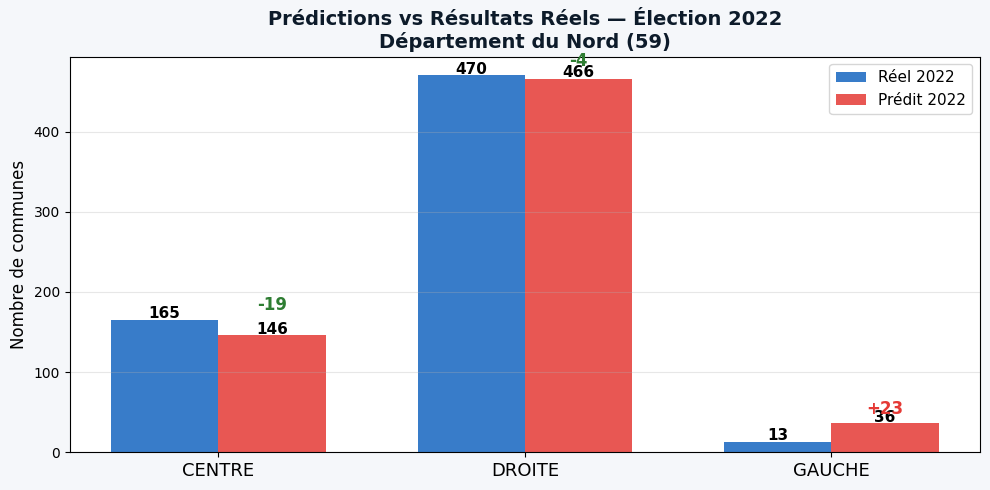

✅ Figure sauvegardée


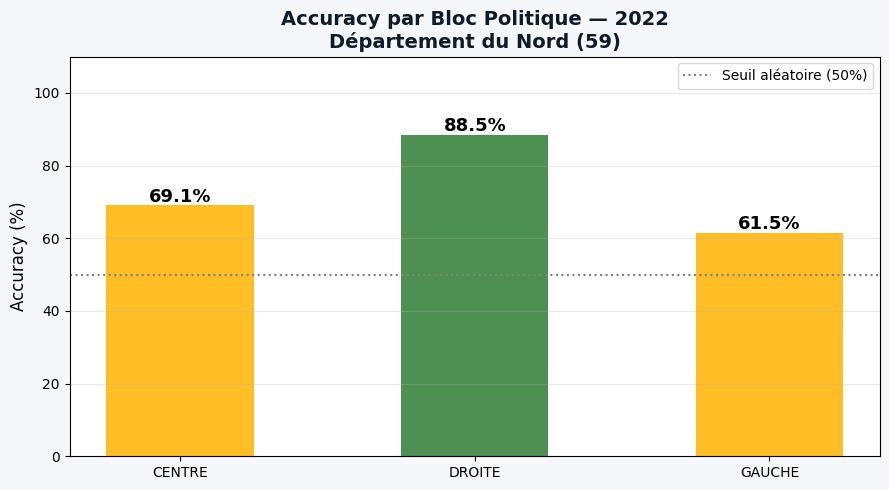

✅ Figure sauvegardée


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── Après avoir obtenu comp (ton DataFrame de comparaison) ──

NAVY  = "#0D1B2A"
BLUE  = "#1565C0"
RED   = "#E53935"
GREEN = "#2E7D32"
GOLD  = "#FFB300"

# ════════════════════════════════════════════════════════
# FIGURE — Justification des écarts prédiction vs réalité
# ════════════════════════════════════════════════════════

# ── FIG A : Écart prédit vs réel par bloc ────────────────
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("#F5F7FA")

blocs       = list(label_names.values())  # CENTRE, DROITE, GAUCHE
pred_counts = [np.sum(comp['prediction_label'] == b) for b in blocs]
reel_counts = [np.sum(comp['target_label']     == b) for b in blocs]

x = np.arange(len(blocs)); w = 0.35
b1 = ax.bar(x - w/2, reel_counts, w, label="Réel 2022",   color=BLUE,  alpha=0.85)
b2 = ax.bar(x + w/2, pred_counts, w, label="Prédit 2022", color=RED,   alpha=0.85)

for b in list(b1) + list(b2):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+2,
            str(int(b.get_height())), ha="center",
            fontsize=11, fontweight="bold")

# Flèches montrant l'écart
for i, (r, p) in enumerate(zip(reel_counts, pred_counts)):
    ecart = p - r
    couleur = RED if ecart > 0 else GREEN
    signe   = "+" if ecart > 0 else ""
    ax.annotate(f"{signe}{ecart}",
                xy=(i + w/2, max(r, p) + 12),
                ha="center", fontsize=12,
                fontweight="bold", color=couleur)

ax.set_title("Prédictions vs Résultats Réels — Élection 2022\nDépartement du Nord (59)",
             fontsize=14, fontweight="bold", color=NAVY)
ax.set_xticks(x)
ax.set_xticklabels(blocs, fontsize=13)
ax.set_ylabel("Nombre de communes", fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("outputs/mc_fig9_predit_vs_reel.png",
            dpi=160, bbox_inches="tight", facecolor="#F5F7FA")
plt.show()
print("✅ Figure sauvegardée")


# ── FIG B : Accuracy par bloc + explication ──────────────
fig2, ax2 = plt.subplots(figsize=(9, 5))
fig2.patch.set_facecolor("#F5F7FA")

accs_par_bloc = []
for b in blocs:
    sub = comp[comp['target_label'] == b]
    acc = sub['correct'].mean() * 100 if len(sub) > 0 else 0
    accs_par_bloc.append(acc)

couleurs_barres = [GREEN if a >= 70 else GOLD if a >= 50 else RED
                   for a in accs_par_bloc]
bars = ax2.bar(blocs, accs_par_bloc, color=couleurs_barres,
               alpha=0.85, width=0.5)
for bar, acc in zip(bars, accs_par_bloc):
    ax2.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+1,
             f"{acc:.1f}%", ha="center",
             fontsize=13, fontweight="bold")

ax2.axhline(50, color="gray", linestyle=":", linewidth=1.5,
            label="Seuil aléatoire (50%)")
ax2.set_title("Accuracy par Bloc Politique — 2022\nDépartement du Nord (59)",
              fontsize=14, fontweight="bold", color=NAVY)
ax2.set_ylabel("Accuracy (%)", fontsize=12)
ax2.set_ylim(0, 110)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("outputs/mc_fig10_accuracy_par_bloc.png",
            dpi=160, bbox_inches="tight", facecolor="#F5F7FA")
plt.show()
print("✅ Figure sauvegardée")